# IMPORTS

In [ ]:
!pip install transformers==4.27.0

In [ ]:
!pip install hdbscan==0.8.33

In [ ]:
import hdbscan

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
import os

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt')

In [ ]:
import string

In [ ]:
import re

In [ ]:
from tqdm.notebook import tqdm
tqdm.pandas()

In [ ]:
!python -m spacy download it_core_news_sm

In [ ]:
import spacy
nlp = spacy.load("it_core_news_sm")

In [ ]:
from transformers import AutoTokenizer, AutoModel

In [ ]:
import torch
if torch.cuda.is_available():
  dev = 'cuda:0'
else:
    dev = "cpu"
device = torch.device(dev)

In [ ]:
import collections
from collections import Counter

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
np.random.seed(1234)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import string

In [ ]:
from difflib import SequenceMatcher

# LOAD

In [ ]:
# OMISSIS: loading df from local csv file

## DESCRIPTIVE STATISTICS

In [ ]:
import re

def contains_icd9(text):
    if pd.isna(text):
      return False
    # Regex pattern for ICD-9-CM codes excluding '000'
    pattern = r'\b(?!000)(?!742\.59)([EV]?\d{3}(\.\d{1,2}))\b'

    # Search for the pattern in the string
    match = re.search(pattern, text)

    # Return True if a match is found, else False
    return bool(match) if match else False

# Apply the function to the 'QUESITO_DIAGNOSTICO' column
df['has_icd9'] = df['QUESITO_DIAGNOSTICO'].apply(contains_icd9)

# Count unique values in 'QUESITO_DIAGNOSTICO' that contain potential ICD-9 codes
unique_icd9_questions = df.loc[df3['has_icd9'], 'QUESITO_DIAGNOSTICO'].nunique()

print(f"Number of unique 'QUESITO_DIAGNOSTICO' values containing potential ICD-9 codes: {unique_icd9_questions}")

Number of unique 'QUESITO_DIAGNOSTICO' values containing potential ICD-9 codes: 189


In [ ]:
df.COD_ATS_PRESCRITTORE_DESC.nunique()

In [ ]:
df['len'] = df.QUESITO_DIAGNOSTICO.str.len()

In [ ]:
from statsmodels.stats.weightstats import DescrStatsW
wq = DescrStatsW(data=df['len'], weights=df['NUMERO'])
wq.quantile([0.25, 0.5, 0.75])

In [ ]:
df['len'].describe()

In [ ]:
df.NUMERO.sum()

In [ ]:
df['len'].plot(kind='box')

## DESCRIPTIVE PLOTS

In [ ]:
unique_ats = df['COD_ATS_PRESCRITTORE_DESC'].unique()
np.random.shuffle(unique_ats)

ats_mapping = {ats: f"LHA {i+1}" for i, ats in enumerate(unique_ats)}

df['ATS_Coded'] = df['COD_ATS_PRESCRITTORE_DESC'].map(ats_mapping)
ats_mapping

In [ ]:
df['ATS_Coded'] = df['COD_ATS_PRESCRITTORE_DESC'].map(ats_mapping)

<ipython-input-105-4a31f078254c>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_referrals.index, y=yearly_referrals.values, ax=ax[0], palette=palette)
<ipython-input-105-4a31f078254c>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=physician_referrals.index, y=physician_referrals.values, ax=ax[1], palette=palette)
<ipython-input-105-4a31f078254c>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ats_referrals.index, y=ats_referrals.values, ax=ax[2], palette=palette)


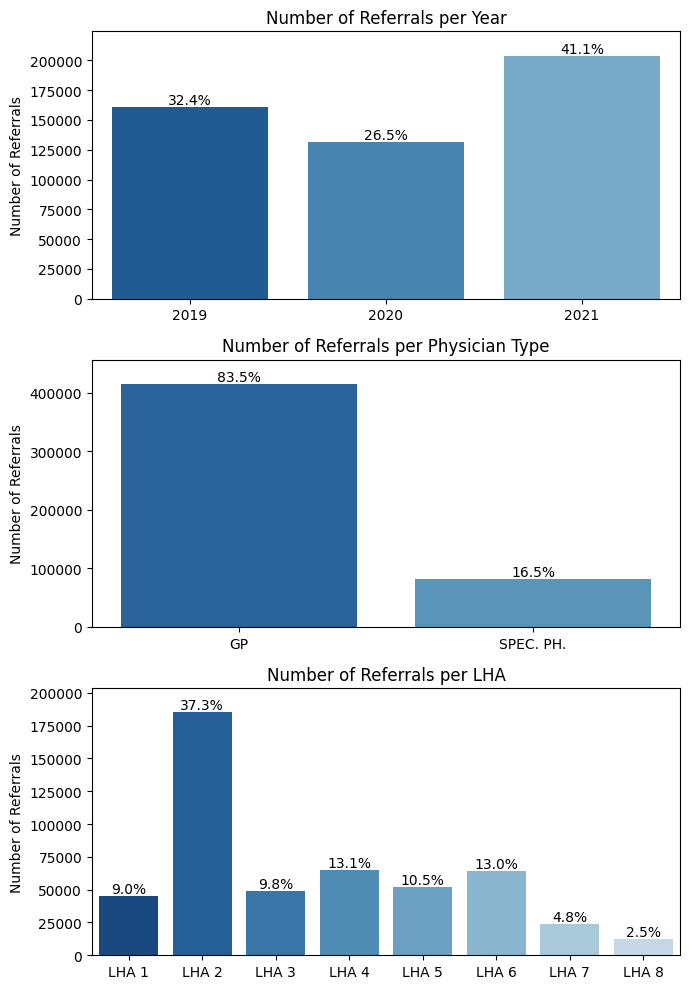

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(7, 10))

# Group data by year and sum 'NUMERO'
yearly_referrals = df.groupby('ANNO')['NUMERO'].sum()

palette = sns.color_palette("light:seagreen", n_colors=df3['ANNO'].nunique() + 2)
palette = sns.color_palette("Blues", n_colors=df3['ANNO'].nunique() + 2)
palette.reverse()
palette = palette[:-2]

# Create the first bar plot (referrals per year)
sns.barplot(x=yearly_referrals.index, y=yearly_referrals.values, ax=ax[0], palette=palette)
ax[0].set_title('Number of Referrals per Year')
ax[0].set_xlabel('')
ax[0].set_ylabel('Number of Referrals')
ax[0].set_ylim(0, yearly_referrals.max() * 1.1)

# Add percentage labels
total_referrals = yearly_referrals.sum()
for i, value in enumerate(yearly_referrals.values):
    percentage = f"{(value / total_referrals) * 100:.1f}%"
    ax[0].text(i, value, percentage, ha='center', va='bottom', fontsize=10)

# Group data by physician type and sum 'NUMERO'
df['TIPO_PRESCRITTORE_CODED'] = df['TIPO_PRESCRITTORE'].map({'MEDICINA GENERALE': 'GP', 'ALTRA TIPOLOGIA': 'SPEC. PH.'})
physician_referrals = df3.groupby('TIPO_PRESCRITTORE_CODED')['NUMERO'].sum()

palette = sns.color_palette("Blues", n_colors=df3['TIPO_PRESCRITTORE_CODED'].nunique() + 2)
palette.reverse()
palette = palette[:-2]

# Create the second bar plot (referrals per physician type)
sns.barplot(x=physician_referrals.index, y=physician_referrals.values, ax=ax[1], palette=palette)
ax[1].set_title('Number of Referrals per Physician Type')
ax[1].set_xlabel('')
ax[1].set_ylabel('Number of Referrals')
ax[1].tick_params(axis='x', rotation=0)  # Rotate x-axis labels for better readability
ax[1].set_ylim(0, physician_referrals.max() * 1.1)

# Add percentage labels
total_referrals_physician = physician_referrals.sum()
for i, value in enumerate(physician_referrals.values):
    percentage = f"{(value / total_referrals_physician) * 100:.1f}%"
    ax[1].text(i, value, percentage, ha='center', va='bottom', fontsize=10)

# Group data by ATS and sum 'NUMERO'
ats_referrals = df.groupby('ATS_Coded')['NUMERO'].sum()

palette = sns.color_palette("Blues", n_colors=df['ATS_Coded'].nunique() + 2)
palette.reverse()
palette = palette[:-2]

# Create the third bar plot (referrals per ATS)
sns.barplot(x=ats_referrals.index, y=ats_referrals.values, ax=ax[2], palette=palette)
ax[2].set_title('Number of Referrals per LHA')
ax[2].set_xlabel('')
ax[2].set_ylabel('Number of Referrals')
ax[2].tick_params(axis='x', rotation=0)  # Rotate x-axis labels for better readability
ax[2].set_ylim(0, ats_referrals.max() * 1.1)

# Add percentage labels
total_referrals_ats = ats_referrals.sum()
for i, value in enumerate(ats_referrals.values):
    percentage = f"{(value / total_referrals_ats) * 100:.1f}%"
    ax[2].text(i, value, percentage, ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


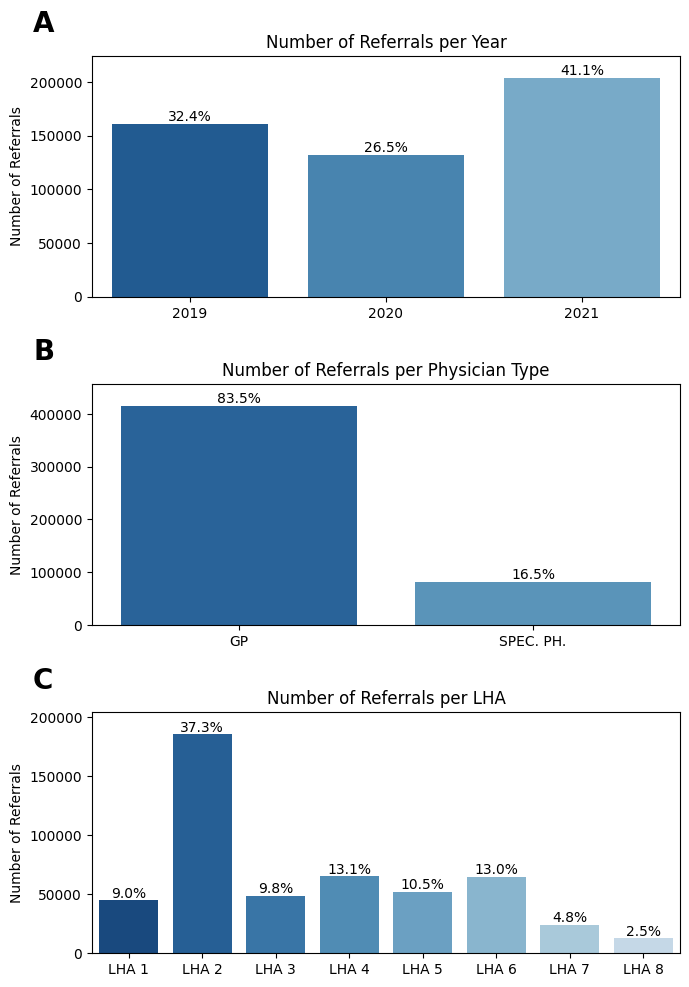

In [ ]:
axs_flat = ax.flat
for n, ax in enumerate(axs_flat):
    ax.text(-0.1, 1.1, string.ascii_uppercase[n], transform=ax.transAxes,
            size=20, weight='bold')

fig.gca().figure.tight_layout()
fig.gca().figure

### ECD + COLON

In [ ]:
df_colon['ATS_Coded'] = df_colon['COD_ATS_PRESCRITTORE_DESC'].map(ats_mapping)

<ipython-input-117-2758deb4d8c0>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_referrals.index, y=yearly_referrals.values, ax=ax[0], palette=palette)
<ipython-input-117-2758deb4d8c0>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_referrals.index, y=yearly_referrals.values, ax=ax[1], palette=palette)
<ipython-input-117-2758deb4d8c0>:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=physician_referrals.index, y=physician_referrals.values, ax=ax[2], palette=palette)
<ipython-input-117-2758deb4d8c0>:77: FutureWarning: 

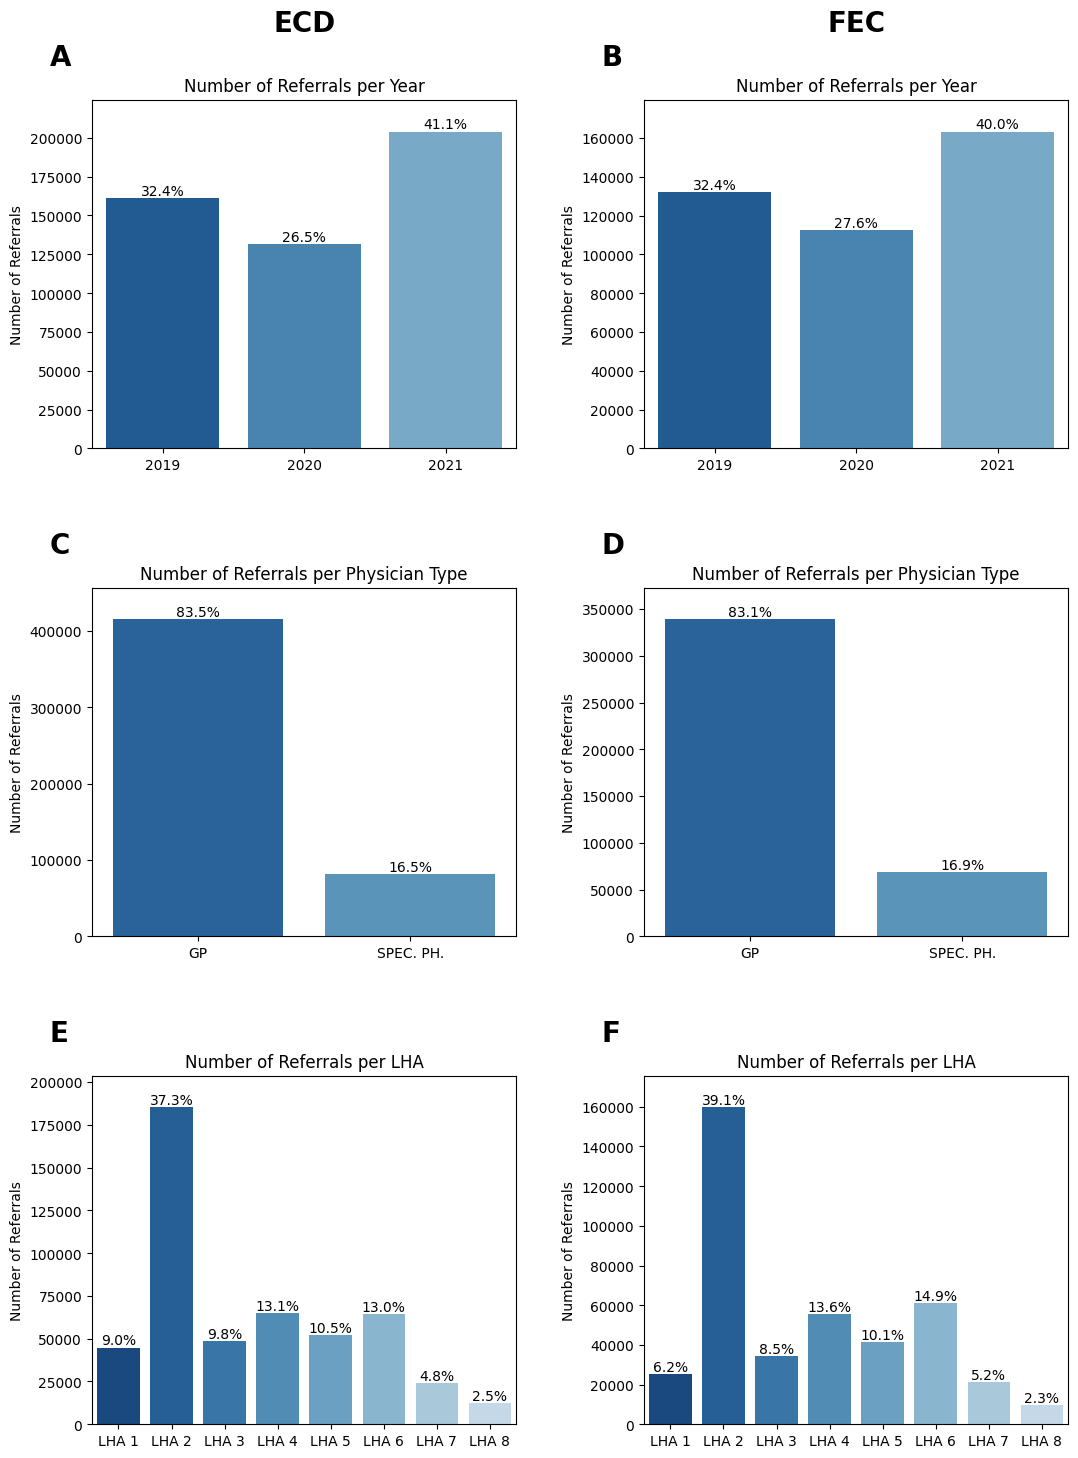

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(12.60, 17.20), gridspec_kw={'wspace': 0.3, 'hspace': 0.4})

ax = ax.flat

### YEAR
palette = sns.color_palette("light:seagreen", n_colors=df3['ANNO'].nunique() + 2)
palette = sns.color_palette("Blues", n_colors=df3['ANNO'].nunique() + 2)
palette.reverse()
palette = palette[:-2]

### YEAR ECD
yearly_referrals = df.groupby('ANNO')['NUMERO'].sum()
# Create the first bar plot (referrals per year)
sns.barplot(x=yearly_referrals.index, y=yearly_referrals.values, ax=ax[0], palette=palette)
ax[0].set_title('Number of Referrals per Year')
ax[0].set_xlabel('')
ax[0].set_ylabel('Number of Referrals')
ax[0].set_ylim(0, yearly_referrals.max() * 1.1)

# Add percentage labels
total_referrals = yearly_referrals.sum()
for i, value in enumerate(yearly_referrals.values):
    percentage = f"{(value / total_referrals) * 100:.1f}%"
    ax[0].text(i, value, percentage, ha='center', va='bottom', fontsize=10)

### YEAR COLON
yearly_referrals = df_colon.groupby('ANNO')['NUMERO'].sum()
# Create the first bar plot (referrals per year)
sns.barplot(x=yearly_referrals.index, y=yearly_referrals.values, ax=ax[1], palette=palette)
ax[1].set_title('Number of Referrals per Year')
ax[1].set_xlabel('')
ax[1].set_ylabel('Number of Referrals')
ax[1].set_ylim(0, yearly_referrals.max() * 1.1)

# Add percentage labels
total_referrals = yearly_referrals.sum()
for i, value in enumerate(yearly_referrals.values):
    percentage = f"{(value / total_referrals) * 100:.1f}%"
    ax[1].text(i, value, percentage, ha='center', va='bottom', fontsize=10)

### PHYSICIAN TYPE

### PH TYPE ECD
df['TIPO_PRESCRITTORE_CODED'] = df['TIPO_PRESCRITTORE'].map({'MEDICINA GENERALE': 'GP', 'ALTRA TIPOLOGIA': 'SPEC. PH.'})
physician_referrals = df.groupby('TIPO_PRESCRITTORE_CODED')['NUMERO'].sum()

palette = sns.color_palette("Blues", n_colors=df['TIPO_PRESCRITTORE_CODED'].nunique() + 2)
palette.reverse()
palette = palette[:-2]

# Create the second bar plot (referrals per physician type)
sns.barplot(x=physician_referrals.index, y=physician_referrals.values, ax=ax[2], palette=palette)
ax[2].set_title('Number of Referrals per Physician Type')
ax[2].set_xlabel('')
ax[2].set_ylabel('Number of Referrals')
ax[2].tick_params(axis='x', rotation=0)  # Rotate x-axis labels for better readability
ax[2].set_ylim(0, physician_referrals.max() * 1.1)

# Add percentage labels
total_referrals_physician = physician_referrals.sum()
for i, value in enumerate(physician_referrals.values):
    percentage = f"{(value / total_referrals_physician) * 100:.1f}%"
    ax[2].text(i, value, percentage, ha='center', va='bottom', fontsize=10)

### PH TYPE COLON
df_colon['TIPO_PRESCRITTORE_CODED'] = df_colon['TIPO_PRESCRITTORE'].map({'MEDICINA GENERALE': 'GP', 'ALTRA TIPOLOGIA': 'SPEC. PH.'})
physician_referrals = df_colon.groupby('TIPO_PRESCRITTORE_CODED')['NUMERO'].sum()

palette = sns.color_palette("Blues", n_colors=df['TIPO_PRESCRITTORE_CODED'].nunique() + 2)
palette.reverse()
palette = palette[:-2]

# Create the second bar plot (referrals per physician type)
sns.barplot(x=physician_referrals.index, y=physician_referrals.values, ax=ax[3], palette=palette)
ax[3].set_title('Number of Referrals per Physician Type')
ax[3].set_xlabel('')
ax[3].set_ylabel('Number of Referrals')
ax[3].tick_params(axis='x', rotation=0)  # Rotate x-axis labels for better readability
ax[3].set_ylim(0, physician_referrals.max() * 1.1)

# Add percentage labels
total_referrals_physician = physician_referrals.sum()
for i, value in enumerate(physician_referrals.values):
    percentage = f"{(value / total_referrals_physician) * 100:.1f}%"
    ax[3].text(i, value, percentage, ha='center', va='bottom', fontsize=10)

### ATS

palette = sns.color_palette("Blues", n_colors=df['ATS_Coded'].nunique() + 2)
palette.reverse()
palette = palette[:-2]

### ATS ECD
ats_referrals = df.groupby('ATS_Coded')['NUMERO'].sum()

# Create the third bar plot (referrals per ATS)
sns.barplot(x=ats_referrals.index, y=ats_referrals.values, ax=ax[4], palette=palette)
ax[4].set_title('Number of Referrals per LHA')
ax[4].set_xlabel('')
ax[4].set_ylabel('Number of Referrals')
ax[4].tick_params(axis='x', rotation=0)  # Rotate x-axis labels for better readability
ax[4].set_ylim(0, ats_referrals.max() * 1.1)

# Add percentage labels
total_referrals_ats = ats_referrals.sum()
for i, value in enumerate(ats_referrals.values):
    percentage = f"{(value / total_referrals_ats) * 100:.1f}%"
    ax[4].text(i, value, percentage, ha='center', va='bottom', fontsize=10)

### ATS COLON
ats_referrals = df_colon.groupby('ATS_Coded')['NUMERO'].sum()

# Create the third bar plot (referrals per ATS)
sns.barplot(x=ats_referrals.index, y=ats_referrals.values, ax=ax[5], palette=palette)
ax[5].set_title('Number of Referrals per LHA')
ax[5].set_xlabel('')
ax[5].set_ylabel('Number of Referrals')
ax[5].tick_params(axis='x', rotation=0)  # Rotate x-axis labels for better readability
ax[5].set_ylim(0, ats_referrals.max() * 1.1)

# Add percentage labels
total_referrals_ats = ats_referrals.sum()
for i, value in enumerate(ats_referrals.values):
    percentage = f"{(value / total_referrals_ats) * 100:.1f}%"
    ax[5].text(i, value, percentage, ha='center', va='bottom', fontsize=10)

### COL TITLES
column_titles = ['ECD', 'FEC']
for col, title in enumerate(column_titles):
    # Set the title for each column
    column_center = (ax[col].get_position().x0 + ax[col].get_position().x1) / 2
    fig.text(
        x=column_center,  # Adjust horizontally based on the number of columns
        y=0.92,  # Position slightly above the subplots
        s=title,
        ha='center',
        fontsize=20,
        fontweight='bold'
    )


### LETTERS
import string
axs_flat = ax
for n, ax in enumerate(axs_flat):
    ax.text(-0.1, 1.1, string.ascii_uppercase[n], transform=ax.transAxes,
            size=20, weight='bold')

fig.gca().figure.tight_layout()
fig.show()

In [ ]:
fig.gca().figure.savefig('summary_desc_barplots_ecd_fec.pdf', bbox_inches='tight')

# PIPELINE

## CLEANING

In [ ]:
from nltk.stem import SnowballStemmer
stemmer_snowball = SnowballStemmer('italian')

In [ ]:
stop = set(stopwords.words('italian'))
stop.remove('nei')

exclude = set(string.punctuation)

df = pd.read_csv("replacements.csv")
replacements = dict(zip(df["remove"], df["replacement"]))

lemmatizations_c = Counter()

def clean(doc):

    try:
        punc_free = ''.join(ch if ch not in exclude else ' ' for ch in doc )
        punc_free = " ".join(punc_free.split()) #replace multiple white spaces, tabs, etc with a single space

        for a, r in replacements.items():
              punc_free = re.sub(a, r, punc_free, flags=re.I)

        lower = " ".join([i for i in punc_free.lower().split()])
        # remove stopwords
        stop_free = ' '.join(i for i in lower.split() if i not in stop)

        # LEMMATIZER
        # #normalized = " ".join(lemma.lemmatize(word) for word in punc_free.split())
        #spacy_doc = nlp(stop_free)
        #normalized = " ".join(token.lemma_ for token in spacy_doc)
        #for token in spacy_doc:
        #  if str(token) != token.lemma_:
        #     lemmatizations_c[(str(token),token.lemma_)] += 1

        # STEMMER
        #normalized = " ".join(stemmer_snowball.stem(word) for word in stop_free.split(' '))

        normalized = re.sub(r'\d+\.?\d*\s*', "", stop_free)
        return normalized
    except:
        print(doc)
        return ''

In [ ]:
word_freq = collections.Counter([w for d in df.QUESITO_DIAGNOSTICO for w in d.split()])

In [ ]:
df_words = pd.DataFrame(word_freq.most_common())

In [ ]:
df_words

### ABBREVIATIONS AND TYPOS

In [ ]:
df_abbr = df_words[df_words[0].str.len() <= 3]

In [ ]:
def contains_number_or_punctuation(word):
  return bool(re.search(r'[0-9!"#$%&\'()*+,-./:;<=>?@\[\]^_`{|}~]', word))

italian_stopwords = set(stopwords.words('italian'))

# Filter out words containing numbers, punctuation, or are Italian stopwords
df_abbr = df_abbr[
    ~df_abbr[0].apply(contains_number_or_punctuation) &
    ~df_abbr[0].str.lower().isin(italian_stopwords)
]

In [ ]:
df_abbr

In [ ]:
def merge_similar_words(df):
    # Convert the first column to lowercase for case-insensitive comparison
    df[0] = df[0].str.lower()

    # Group by the lowercase words and sum the counts
    merged_df = df.groupby(0)[1].sum().reset_index()

    return merged_df

df_abbr = merge_similar_words(df_abbr)
df_abbr.sort_values(by=1, ascending=False)

In [ ]:
threshold_freq = int(len(df)*0.01)

In [ ]:
def find_correction(w):
  words = df_words[(df_words[0]!=w)&(df_words[1]>threshold_freq)]
  words['sim'] = words.apply(lambda x: SequenceMatcher(None, x[0], w).ratio(), axis=1)
  #words = words.sort_values(by='sim', ascending=False)
  words = words[words.sim >= 0.8]
  if len(words) == 0:
    return None
  words.sort_values(by='sim', ascending=False)
  return words.iloc[0][0]

In [ ]:
df_words['corr'] = None

In [ ]:
df_words.loc[df_words[1] <= threshold_freq, 'corr'] = df_words.loc[df_words[1] <= threshold_freq, 0].progress_apply(find_correction)

In [ ]:
df_corr = df_words[(~df_words[0].str.contains('\.|,|\(|\\|\d+|:|\+|-|\)|\>|\<|\'|"|;|\?', regex=True))&(df_words['corr'].notna())&(df_words[1] <= 1)]

In [ ]:
len(df_corr)

In [ ]:
df_words.to_csv('df_words_corr_ecd.csv')

In [ ]:
df['QUESITO_CLEAN'] = df.QUESITO_DIAGNOSTICO.progress_apply(clean)

In [ ]:
# keep only words that actually have a correction
corr_map = (
    df_words.loc[df_words['corr'].notna(), [0, 'corr']]
    .set_index(0)['corr']
    .to_dict()
)

def apply_map(text, m=corr_map):
    return ' '.join(m.get(tok, tok) for tok in text.split())

df['QUESITO_CLEAN'] = df['QUESITO_CLEAN'].apply(apply_map)


In [ ]:
from collections import Counter

def count_short_words(df):
    word_counts = Counter()
    for text in tqdm(df['QUESITO_CLEAN'].unique()):
            words = text.split()
            for word in words:
                if len(word) <= 3:
                    word_counts[word] += 1
    return word_counts


word_freq = count_short_words(df)

In [ ]:
word_freq.most_common()

In [ ]:
df.QUESITO_CLEAN.nunique()

In [ ]:
clean_corpus = df.QUESITO_CLEAN.apply(lambda x: x.split() if not pd.isna(x) else [''])

In [ ]:
word_freq = collections.Counter([w for d in clean_corpus for w in d])

In [ ]:
df_words = pd.DataFrame(word_freq.most_common()).sort_values(1, ascending=True)

In [ ]:
word_freq_dict = dict(word_freq.most_common())

## EVAL

### LABELS TO KEEP

Labels with frequency > 10 to keep in the evaluation, the remaining ones are merged with 'altro' (other)

In [ ]:
labels_to_keep = ['addominalgia',
 'alvo alterato',
 'anemia',
 'diarrea cronica',
 'diverticolite',
 'diverticolosi',
 'malattie infiammatorie croniche intestinali',
 'polipi',
 'prevenzione',
 'sanguinamento',
 'stipsi',
 'tumore colon',
 'altro']

In [ ]:
labels_to_keep = ['varici intervento', 'trombosi', 'tromboflebite', 'safenectomia', 'ulcera', 'insufficienza venosa', 'parestesie', 'edema', 'varici', 'dolore', 'vasculopatia', 'claudicatio', 'altro']

### SUMMARY

In [ ]:
def my_textrank(df, threshold=0.8):
    txt = df['QUESITO_CLEAN'].str.cat(sep='. ')
    if len(txt)==0:
      return ''
    words = re.split(',|;|\s|\.', txt)
    words = [w.lower() for w in words if w != '']
    words = [w for w in words if not w in stopwords.words('italian')]
    word_freq = collections.Counter(words)
    word_freq_dict = dict(word_freq.most_common())
    #return word_freq_dict
    total = len(words)
    word_freq_dict = {key: value / total for key, value in word_freq_dict.items()}
    freq_words = {}
    while len(freq_words)<2 and threshold > 0.000001:
      freq_words = {key: value for key, value in word_freq_dict.items() if value > threshold}
      threshold /= 2
    if len(freq_words) > 0:
      return [k for k,v in freq_words.items()]
    else:
      return ['']

In [ ]:
summary = {}
for j in tqdm(range(n_clusters)):
  summary[ordered_clusters[j]] = my_textrank(df_sample[df_sample[name]==ordered_clusters[j]])

In [ ]:
df_res = pd.DataFrame(columns=['cluster', 'len', 'keywords'])
for j in range(n_clusters):
  gruppo = df_sample[df_sample[name]==ordered_clusters[j]]
  l = len(gruppo[['QUESITO_CLEAN']])
  print(f"{ordered_clusters[j]} - {sum(gruppo.NUMERO)} - {summary[j]}")
  df_res = df_res.append({'cluster':ordered_clusters[j], 'len': sum(gruppo.NUMERO), 'keywords': ' '.join(summary[j])}, ignore_index=True)

### MAPPING

In [ ]:
from difflib import get_close_matches

In [ ]:
qd_good_embs = [get_umberto_emb(q, umberto, tokenizer) for q in qd_buoni]
qd_bad_embs = [get_umberto_emb(q, umberto, tokenizer) for q in qd_cattivi]

In [ ]:
def get_mapping_qd(keywords):
  keyword_emb = get_umberto_emb(keywords, model, tokenizer)

  sim_good = cosine_similarity([keyword_emb], qd_buoni_embs)[0]
  sim_bad = cosine_similarity([keyword_emb], qd_cattivi_embs)[0]

  max_good = np.max(sim_good)
  max_bad = np.max(sim_bad)


  if max_good > max_bad and max_good > 0.5:
    return [qd_good_embs[np.argmax(sim_good)]]
  elif max_bad > 0.5:
    return [qd_bad_embs[np.argmax(sim_bad)]]
  else:
    return None

In [ ]:
df_res['mapping'] = df_res['keywords'].apply(get_mapping_qd)

In [ ]:
df_export = df_testo[df_testo.columns.drop(list(df_sample.filter(regex='U\d+')))]

In [ ]:
df_export_2 = df_testo[df_testo.QUESITO_CLEAN.isin(df_export.QUESITO_CLEAN)][['ANNO', 'TIPO_PRESCRITTORE', 'COD_ATS_PRESCRITTORE_DESC', 'NUMERO', 'QUESITO_CLEAN', 'QUESITO_DIAGNOSTICO']].merge(df_export, on='QUESITO_CLEAN', how='left', suffixes=('', '_exp'))

In [ ]:
# Group by 'cluster_summary' and 'name' and get the size and sum of 'NUMERO'
grouped_df = df_export_2.groupby(['cluster_summary']).agg({'NUMERO': ['size', 'sum']})

grouped_df = grouped_df.reset_index()

grouped_df.to_excel('clusters_ecd_summarized.xlsx')

grouped_df

In [ ]:
labels_to_keep = ['varici intervento', 'trombosi', 'tromboflebite', 'safenectomia', 'ulcera', 'insufficienza venosa', 'parestesie', 'edema', 'varici', 'dolore', 'vasculopatia', 'claudicatio', 'insufficienza circolatoria', 'altro']
df_labels['LABEL_FIXED'] = df_labels.LABEL
df_labels.loc[(df_labels.LABEL.notna())&(~df_labels.LABEL.isin(labels_to_keep)),'LABEL_FIXED'] = 'altro'

In [ ]:
mapping_clusters_labels = {}

for k, v in summary.items():
    # Assume `v` is a string or a list of keywords
    label = get_mapping_qd(v)  # This returns a list or None

    if label:
        mapping_clusters_labels[k] = label[0]  # Take the best match
    else:
        mapping_clusters_labels[k] = 'altro'

In [ ]:
df_export_3 = df_export_2[df_export_2.QUESITO_DIAGNOSTICO.isin(df_labels[df_labels.LABEL.notna()].QUESITO_DIAGNOSTICO)]
df_export_3 = df_export_3.merge(df_labels.loc[df_labels.LABEL_FIXED.notna(), ['QUESITO_DIAGNOSTICO', 'LABEL_FIXED']], on='QUESITO_DIAGNOSTICO', how='left')
df_export_3 = df_export_3.groupby(['QUESITO_CLEAN', 'QUESITO_DIAGNOSTICO', name, 'LABEL_FIXED'])['NUMERO'].sum().reset_index()
df_export_3

In [ ]:
df_export_2['cluster_summary'] = df_export_2[name].map(lambda x: ';'.join(summary[x]))

In [ ]:
df_export_3['cluster_summary'] = df_export_3[name].map(lambda x: ';'.join(summary[x]))

In [ ]:
df_export_2['LABEL_CLUSTER'] = df_export_2[name].map(mapping_clusters_labels)

In [ ]:
df_export_3['LABEL_CLUSTER'] = df_export_3[name].map(mapping_clusters_labels)

### METRICS

In [ ]:
from sklearn.metrics import classification_report

df_export_4 = df_export_3#[df_export_3[name] != -1]
print(classification_report(df_export_4.LABEL_FIXED, df_export_4.LABEL_CLUSTER, digits=4))

In [ ]:
from sklearn.metrics import classification_report

df_export_4 = df_export_3#[df_export_3[name] != -1]
print(classification_report(df_export_4.LABEL_FIXED, df_export_4.LABEL_CLUSTER, digits=4,  sample_weight=df_export_4.NUMERO))

In [ ]:
appr_classes = pd.read_csv('appr_classes_ecd.csv')iloc[:, 0].tolist()
inappr_classes = pd.read_csv('inappr_classes_ecd.csv')iloc[:, 0].tolist()
uncert_classes = pd.read_csv('uncert_classes_ecd.csv')iloc[:, 0].tolist()

In [ ]:
def get_appr_class(x):
  if x in appr_classes:
    return 1
  if x in inappr_classes:
    return 0
  if x in uncert_classes:
    return 2
  return 3

In [ ]:
df_export_4['LABEL_APPRO'] = df_export_4.LABEL_FIXED.apply(lambda x: get_appr_class(x))
df_export_4['CLUSTER_APPRO'] = df_export_4.LABEL_CLUSTER.apply(lambda x: get_appr_class(x))

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(df_export_4.LABEL_APPRO, df_export_4.CLUSTER_APPRO, digits=4))

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(df_export_4.LABEL_APPRO, df_export_4.CLUSTER_APPRO, digits=4, sample_weight=df_export_4.NUMERO))

In [ ]:
df_export_4[df_export_4['LABEL_FIXED']!=df_export_4['LABEL_CLUSTER']]

In [ ]:
df_export_4.to_csv('df_export_4_tf_idf.csv')

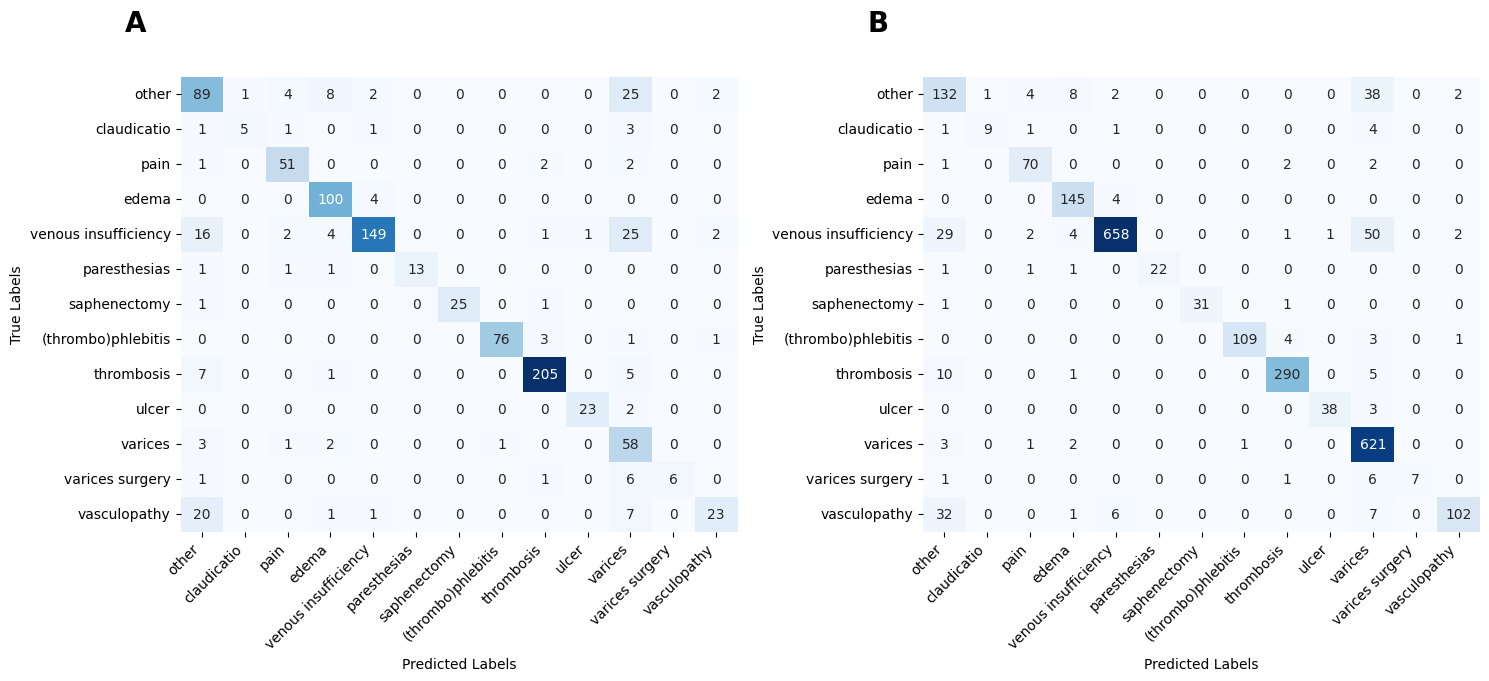

In [ ]:
from sklearn.metrics import confusion_matrix

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,7));

labels = sorted(df_export_4.LABEL_FIXED.unique())
labels_trans = ['other', 'claudicatio', 'pain', 'edema', 'venous insufficiency', 'paresthesias', 'saphenectomy', '(thrombo)phlebitis', 'thrombosis', 'ulcer', 'varices', 'varices surgery', 'vasculopathy']
cm = confusion_matrix(df_export_4.LABEL_FIXED, df_export_4.SIM_DIAGN_FIXED, labels=labels)#, sample_weight=df_export_4.NUMERO)


sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_trans, yticklabels=labels_trans, cbar=False, ax=axs[0])
axs[0].set_xticklabels(labels_trans, rotation=45, ha='right')
axs[0].set_xlabel("Predicted Labels")
axs[0].set_ylabel("True Labels")
axs[0].set_title("")
#plt.savefig('confusion_matrix.pdf', bbox_inches='tight')

cm = confusion_matrix(df_export_4.LABEL_FIXED, df_export_4.SIM_DIAGN_FIXED, labels=labels, sample_weight=df_export_4.NUMERO)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_trans, yticklabels=labels_trans, cbar=False, ax=axs[1])
axs[1].set_xlabel("Predicted Labels")
axs[1].set_xticklabels(labels_trans, rotation=45, ha='right')
axs[1].set_ylabel("True Labels")
axs[1].set_title("")

import string
axs_flat = axs.flat
for n, ax in enumerate(axs_flat):
    ax.text(-0.1, 1.1, string.ascii_uppercase[n], transform=ax.transAxes,
            size=20, weight='bold')


fig.gca().figure.tight_layout()
fig.gca().figure.savefig('confusion_matrix_2.pdf')
fig.gca().figure.show()


## CONFUSION MATRICES PAPER PLOT

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15,15), gridspec_kw={ 'hspace': 0.5, 'wspace': 0.5});
TICK_LABELS_SIZE = 8
LABEL_SIZE = 8
ANN_SIZE = 11
axs = axs.flat

### ECD
labels_trans = ['other', 'claudicatio', 'pain', 'edema', 'venous insufficiency', 'paresthesias', 'saphenectomy', '(thrombo)phlebitis', 'thrombosis', 'ulcer', 'varices', 'varices surgery', 'vasculopathy']
cm = cm_vai_ecd


sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_trans, yticklabels=labels_trans, cbar=False, ax=axs[0], annot_kws={"size": ANN_SIZE} )
axs[0].set_xticklabels(labels_trans, rotation=45, ha='right', fontsize=TICK_LABELS_SIZE)
axs[0].set_yticklabels(labels_trans,fontsize=TICK_LABELS_SIZE)
axs[0].set_xlabel("Predicted Labels", fontsize=LABEL_SIZE)
axs[0].set_ylabel("True Labels", fontsize=LABEL_SIZE)
axs[0].set_title("")

cm = cm_vai_fec

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_trans, yticklabels=labels_trans, cbar=False, ax=axs[1],annot_kws={"size": ANN_SIZE})
axs[1].set_xlabel("Predicted Labels", fontsize=LABEL_SIZE)
axs[1].set_yticklabels(labels_trans,fontsize=TICK_LABELS_SIZE)
axs[1].set_xticklabels(labels_trans, rotation=45, ha='right', fontsize=TICK_LABELS_SIZE)
axs[1].set_ylabel("True Labels", fontsize=LABEL_SIZE)
axs[1].set_title("")

### COLON

labels_trans = ['abdominal pain', 'other', 'altered bowel', 'anaemia', 'chronic diarrhoea', 'diverticulitis', 'diverticulosis', 'chronic inflammatory bowel disease', 'polyps', 'family history / prevention', 'bleeding', 'constipation', 'colon cancer']
cm = confusion_matrix(df_labels.LABEL_FIXED, df_labels.DIAGNOSI_FIXED, labels=labels)#, sample_weight=df_export_4.NUMERO)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_trans, yticklabels=labels_trans, cbar=False, ax=axs[2], annot_kws={"size": ANN_SIZE})
axs[2].set_xticklabels(labels_trans, rotation=45, ha='right', fontsize=TICK_LABELS_SIZE)
axs[2].set_yticklabels(labels_trans,fontsize=TICK_LABELS_SIZE)
axs[2].set_xlabel("Predicted Labels", fontsize=LABEL_SIZE)
axs[2].set_ylabel("True Labels", fontsize=LABEL_SIZE)
axs[2].set_title("")

cm = confusion_matrix(df_labels.LABEL_FIXED, df_labels.DIAGNOSI_FIXED, labels=labels, sample_weight=df_labels.NUMERO)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_trans, yticklabels=labels_trans, cbar=False, ax=axs[3], annot_kws={"size": ANN_SIZE})
axs[3].set_xlabel("Predicted Labels", fontsize=LABEL_SIZE)
axs[3].set_xticklabels(labels_trans, rotation=45, ha='right', fontsize=TICK_LABELS_SIZE)
axs[3].set_yticklabels(labels_trans,fontsize=TICK_LABELS_SIZE)
axs[3].set_ylabel("True Labels", fontsize=LABEL_SIZE)
axs[3].set_title("")

### LETTERS

import string
axs_flat = axs
for n, ax in enumerate(axs_flat):
    ax.text(-0.1, 1.1, string.ascii_uppercase[n], transform=ax.transAxes,
            size=18, weight='bold')

# Add row titles
row_titles = ["ECD", "FEC"]
for i, title in enumerate(row_titles):
  row_y = (axs[i*2].get_position().y1)
  fig.text(
        x=0.5,  # Center horizontally
        y=row_y + 0.07,
        s=title,
        ha='center',
        va='center',
        fontsize=20,
        fontweight='bold'
  )


fig.gca().figure.tight_layout()
#fig.gca().figure.savefig('confusion_matrix_2.pdf')
fig.gca().figure.show()


In [ ]:
fig.gca().figure.savefig('confusion_matrix_colon_vai_2x2_large_300dpi.pdf', bbox_inches='tight', dpi=300)

## TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

tf_idf_vectorizer = TfidfVectorizer(lowercase=False, max_features=1000, stop_words=[])
cv_vectorizer = CountVectorizer(tokenizer=lambda doc: doc, lowercase=False)

In [ ]:
clean_corpus = df.QUESITO_CLEAN.to_list()

In [ ]:
tf_idf_arr = tf_idf_vectorizer.fit_transform(clean_corpus)

In [ ]:
vocab_tf_idf = tf_idf_vectorizer.get_feature_names_out()
len(vocab_tf_idf)

In [ ]:
vocab_tf_idf

In [ ]:
df_sample = pd.concat([df_sample, pd.DataFrame(tf_idf_arr.todense())], axis=1)

In [ ]:
df_testo = df

In [ ]:
df_testo.columns = df_testo.columns.astype(str)
emb_cols = [col for col in df_testo.columns if re.match('^\d+', col)]
df_quesiti = df_testo.groupby(by=emb_cols + ['QUESITO_CLEAN'])['NUMERO'].sum().reset_index()

In [ ]:
df_quesiti = df_quesiti.sort_values(by='NUMERO', ascending=False)

In [ ]:
df_sample = df_quesiti[:]

In [ ]:
df_sample = df_sample.reset_index(drop=True)

In [ ]:
X = df_sample.filter(regex=("^\d.*")) #FOR TF-IDF

In [ ]:
X

,0,1,2,3,4,5,6,7,8,9,...,1164,1165,1166,1167,1168,1169,1170,1171,1172,1173
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288195,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
288196,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
288197,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
288198,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### DIM RED

In [ ]:
from sklearn.decomposition import PCA, TruncatedSVD

In [ ]:
tf_idf_arr

<30000x1000 sparse matrix of type '<class 'numpy.float64'>'
	with 146707 stored elements in Compressed Sparse Row format>

In [ ]:
tsvd = TruncatedSVD(n_components=500)
tsvd = tsvd.fit(tf_idf_arr)

In [ ]:
sum(tsvd.explained_variance_ratio_)

0.8766339921486834

In [ ]:
for i in [50, 100, 200]:
  tsvd = TruncatedSVD(n_components=i)
  tsvd.fit(X)
  print(i, sum(tsvd.explained_variance_ratio_))

In [ ]:
tsvd = TruncatedSVD(n_components=500)
X_red = tsvd.fit_transform(tf_idf_arr)

In [ ]:
X_red = pd.DataFrame(X_red)

### K-MEANS

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
Sum_of_squared_distances = []
K = range(2,50)
for k in tqdm(K):
    km = KMeans(n_clusters=k)
    km = km.fit(X_red)
    Sum_of_squared_distances.append(km.inertia_)
plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum of squared distances')
plt.title('Selection of number of clusters')
plt.show()

In [ ]:
unclustered = X_red.index

In [ ]:
n_clusters=40
clusterer = KMeans(n_clusters=n_clusters, random_state=1234)
cluster_labels = clusterer.fit_predict(X_red.loc[unclustered])

In [ ]:
cluster_labels = [c if c!=-1 else c for c in cluster_labels]

In [ ]:
np.unique(cluster_labels)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39], dtype=int32)

In [ ]:
name='tf-idf'

In [ ]:
df_sample.loc[unclustered, name] = cluster_labels

## BERT UTILS

In [ ]:
def load_umberto(name):
  if name=='umberto-base-uncased':
    model = umberto = AutoModel.from_pretrained("Musixmatch/umberto-wikipedia-uncased-v1")
    tokenizer = AutoTokenizer.from_pretrained("Musixmatch/umberto-wikipedia-uncased-v1")
  else:
    if name=='umberto-base':
      model =  AutoTokenizer.from_pretrained("Musixmatch/umberto-commoncrawl-cased-v1")
    elif name=='umberto-medicina':
      model = AutoModel.from_pretrained(#LOCAL PATH)
    elif name=='umberto-malattie':
      model = umberto = AutoModel.from_pretrained(#LOCAL PATH)
    elif name=='umberto-e3c':
      model = umberto = AutoModel.from_pretrained(#LOCAL PATH)
    else:
      raise ValueError('Unrecognized name!')
    tokenizer = AutoTokenizer.from_pretrained("Musixmatch/umberto-commoncrawl-cased-v1")
  return model,tokenizer

In [ ]:
def get_umberto_emb(str, model, tokenizer):
    encoded_input = tokenizer.encode(str)
    input_ids = torch.tensor(encoded_input).unsqueeze(0).to(device)  # Batch size 1
    #return umberto(input_ids)[0][0]
    return model(input_ids)[0][0].mean(axis=0)
    #last_hidden_states = outputs[0]  # The last hidden-state is the first element of the output

    #return last_hidden_states[0].mean(axis=0)

In [ ]:
def add_bert_embeddings(model, tokenizer, df_testo, text_col):
  model.eval()
  model.to(device)
  with torch.no_grad():
    df_testo['Umberto'] = df_testo[text_col].progress_apply(lambda x: get_umberto_emb(x, model, tokenizer))
  umb_dict = {str(key): dict(enumerate(emb.cpu().numpy())) for (key, emb) in dict(enumerate(df_testo['Umberto'])).items()}
  umb_df = pd.DataFrame.from_dict(umb_dict, orient='index')
  column_remapping = {i:'U'+str(i) for i in range(len(umb_df.columns))}
  umb_df.rename(columns=column_remapping, inplace=True)
  df_testo = df_testo[df_testo.columns.drop(list(df_testo.filter(regex='U\d+')))]
  df_testo.drop('level_0', axis=1, inplace=True, errors='ignore')
  return pd.concat([df_testo.reset_index(), umb_df.reset_index()], axis=1)

In [ ]:
umberto, tokenizer = load_umberto('umberto-e3c')

## UMBERTO

In [ ]:
df_testo = df

In [ ]:
df_testo = add_bert_embeddings(umberto, tokenizer, df_testo, 'QUESITO_CLEAN')

In [ ]:
df_testo.to_csv('df_testo_umberto_e3c_ecd.csv')

In [ ]:
emb_cols = [col for col in df_testo.columns if re.match('U\d+', col)]
df_quesiti = df_testo.groupby(by=emb_cols + ['QUESITO_CLEAN'])['NUMERO'].sum().reset_index()

In [ ]:
len(df_quesiti)

In [ ]:
df_quesiti = df_quesiti.sort_values(by='NUMERO', ascending=False)

In [ ]:
df_quesiti = df_quesiti.sample(frac=1)

In [ ]:
df_quesiti[:50000].NUMERO.sum() / df_quesiti.NUMERO.sum()

In [ ]:
df_quesiti[:50000].NUMERO.sum()

In [ ]:
df_labels = pd.read_excel('df_export_1_ecd_labels.xlsx', index_col=0)

In [ ]:
df_labels.groupby('LABEL').size()

In [ ]:
df_labels['QUESITO_CLEAN'] = df_labels.QUESITO_DIAGNOSTICO.progress_apply(clean)

In [ ]:
df_sample = df_labels.merge(df_quesiti, on='QUESITO_CLEAN', how='left', suffixes=('labels', '')).drop(['Unnamed: 11', 'Unnamed: 12', 'DOUBLE', 'TYPO', 'ABBR', 'umb_e3c', 'cluster_summary', 'QUESITO_DIAGNOSTICO', 'NUMERO_exp'], axis=1).groupby(by=emb_cols + ['QUESITO_CLEAN'])['NUMERO'].sum().reset_index()
df_sample

In [ ]:
start_index = 0
to_index = 30000

In [ ]:
df_sample = df_quesiti[start_index:to_index]

In [ ]:
df_sample = df_quesiti

In [ ]:
df_sample = df_sample.reset_index(drop=True)

In [ ]:
X = df_sample.filter(regex=("U\d.*")) #FOR UMBERTO

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
for i in [50, 100, 200, 300]:
  pca = PCA(n_components=i)
  pca.fit(X)
  print(i, sum(pca.explained_variance_ratio_))

In [ ]:
pca = PCA(n_components=50)
X_red = pca.fit_transform(X)

In [ ]:
import umap
reducer = umap.UMAP(n_components=50, random_state=1234)
X_red = reducer.fit_transform(X)

In [ ]:
X_red

### HDBSCAN

In [ ]:
import hdbscan

In [ ]:
X_red = pd.DataFrame(X_red, index=X.index)

In [ ]:
name = 'umb_e3c_ecd_hdbscan'

In [ ]:
unclustered=df_sample.index

In [ ]:
min_cluster_size = 500

In [ ]:
n_clusters = 0

In [ ]:
from sklearn.metrics import pairwise_distances
print(min_cluster_size)
distances = pairwise_distances(X_red.loc[unclustered], metric='cosine')

To be repeated:

In [ ]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, metric='precomputed', min_samples=1, cluster_selection_epsilon=0.00)
#clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=1, cluster_selection_method='leaf')#, cluster_selection_epsilon=0.00)
cluster_labels = clusterer.fit_predict(distances)
cluster_labels = [c+n_clusters if c!=-1 else c for c in cluster_labels]
min_cluster_size //= 2
df_sample.loc[unclustered, name] = cluster_labels
unclustered = df_sample[df_sample[name] == -1].index
n_clusters = max(cluster_labels)+1

In [ ]:
np.unique(cluster_labels)

In [ ]:
ordered_clusters = np.sort(df_sample[name].unique())
n_clusters = len(ordered_clusters)
n_clusters

In [ ]:
df_sample.NUMERO.sum()

In [ ]:
df_sample.groupby(name).size()
#df_sample.groupby(name).NUMERO.sum()

#### HYPERPARAMS

In [ ]:
name = 'umberto_e3c_ecd_hdbscan'

In [ ]:
unclustered=df_sample.index

In [ ]:
from sklearn.metrics import pairwise_distances

In [ ]:
min_cluster_size = 500
n_clusters = 0

In [ ]:
def cluster_hdbscan(X_red, df_sample, min_cluster_size, n_clusters, unclustered, name, min_samples=1, cluster_selection_epsilon=0):

  while min_cluster_size >= 20:
    distances = pairwise_distances(X_red.loc[unclustered], metric='cosine')
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, metric='precomputed', min_samples=min_samples, cluster_selection_epsilon=0.00)
    #clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=1, cluster_selection_method='leaf')#, cluster_selection_epsilon=0.00)
    #cluster_labels = clusterer.fit_predict(X_red.astype('float64'))
    cluster_labels = clusterer.fit_predict(distances)
    cluster_labels = [c+n_clusters if c!=-1 else c for c in cluster_labels]
    df_sample.loc[unclustered, name] = cluster_labels
    unclustered = df_sample[df_sample[name] == -1].index
    n_clusters = max(cluster_labels)+1
    min_cluster_size //= 2


  ordered_clusters = np.sort(df_sample[name].unique())
  n_clusters = len(ordered_clusters)

  summary = {}
  for j in tqdm(range(n_clusters)):
    summary[ordered_clusters[j]] = my_textrank(df_sample[df_sample[name]==ordered_clusters[j]])

  df_export = df_sample[df_sample.columns.drop(list(df_sample.filter(regex='U\d+')))]
  df_export_2 = df_testo[df_testo.QUESITO_CLEAN.isin(df_export.QUESITO_CLEAN)][['ANNO', 'TIPO_PRESCRITTORE', 'COD_ATS_PRESCRITTORE_DESC', 'NUMERO', 'QUESITO_CLEAN', 'QUESITO_DIAGNOSTICO']].merge(df_export, on='QUESITO_CLEAN', how='left', suffixes=('', '_exp'))
  df_export_2['cluster_summary'] = df_export_2[name].map(lambda x: ';'.join(summary[x]))

  df_labels['LABEL_FIXED'] = df_labels.LABEL
  df_labels.loc[(df_labels.LABEL.notna())&(~df_labels.LABEL.isin(labels_to_keep)),'LABEL_FIXED'] = 'altro'

  mapping_clusters_labels = {}

  for k, v in summary.items():
      # Assume `v` is a string or a list of keywords
      label = get_mapping_qd(v)  # This returns a list or None

      if label:
          mapping_clusters_labels[k] = label[0]  # Take the best match
      else:
          mapping_clusters_labels[k] = 'altro'

  df_export_3 = df_export_2[df_export_2.QUESITO_DIAGNOSTICO.isin(df_labels[df_labels.LABEL.notna()].QUESITO_DIAGNOSTICO)]
  df_export_3 = df_export_3.merge(df_labels.loc[df_labels.LABEL_FIXED.notna(), ['QUESITO_DIAGNOSTICO', 'LABEL_FIXED']], on='QUESITO_DIAGNOSTICO', how='left')
  df_export_3 = df_export_3.groupby(['QUESITO_CLEAN', 'QUESITO_DIAGNOSTICO', name, 'LABEL_FIXED'])['NUMERO'].sum().reset_index()

  df_export_2['LABEL_CLUSTER'] = df_export_2[name].map(mapping_clusters_labels)
  df_export_2['cluster_summary'] = df_export_2[name].map(lambda x: ';'.join(summary[x]))

  df_export_3['LABEL_CLUSTER'] = df_export_3[name].map(mapping_clusters_labels)
  df_export_3['cluster_summary'] = df_export_3[name].map(lambda x: ';'.join(summary[x]))

  df_export_4 = df_export_3#[df_export_3[name] != -1]

  report = classification_report(df_export_4.LABEL_FIXED, df_export_4.LABEL_CLUSTER, digits=4, output_dict=True)

  # Extract macro-averaged metrics
  macro_precision = report['macro avg']['precision']
  macro_recall = report['macro avg']['recall']
  macro_f1 = report['macro avg']['f1-score']

  return macro_precision, macro_recall, macro_f1

In [ ]:
cluster_hdbscan(X_red, df_sample, min_cluster_size, n_clusters, unclustered, name)

In [ ]:
import matplotlib.pyplot as plt
from itertools import product

# Define the parameter grid
param_grid = {
    'min_cluster_size': [20, 50, 100, 200, 500],
    'min_samples': [None, 1, 5, 10, 20],
    'cluster_selection_epsilon': [0.0, 0.1, 0.5],
}

# Create all parameter combinations
param_names = list(param_grid.keys())
param_combinations = list(product(*param_grid.values()))

# Placeholder for results
results = []

# Run grid search
for combo in tqdm(param_combinations, desc="Grid Search"):
    params = dict(zip(param_names, combo))
    try:
        p, r, f1 = cluster_hdbscan(
            X_red=X_red,
            df_sample=df_sample,
            min_cluster_size=params['min_cluster_size'],
            n_clusters=0,
            unclustered=unclustered,
            name="gridsearch",
            min_samples=params['min_samples'],
            cluster_selection_epsilon=params['cluster_selection_epsilon']
        )
        results.append({
            **params,
            'prec': p,
            'rec': r,
            'f1': f1
        })
    except Exception as e:
        print(f"Error for params {params}: {e}")
        continue

# Convert results to DataFrame
df_results = pd.DataFrame(results)

In [ ]:
df_results.to_excel('hdbscan_grid_search_results.xlsx')

In [ ]:
df_results

### K-MEANS

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
X_red = pd.DataFrame(X_red)

In [ ]:
Sum_of_squared_distances = []
K = range(2,151)
for k in tqdm(K):
    km = KMeans(n_clusters=k)
    km = km.fit(X_red)
    Sum_of_squared_distances.append(km.inertia_)
plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum of squared distances')
plt.title('Selection of number of clusters')
plt.show()

In [ ]:
unclustered = X_red.index

#### RUN K-MEANS

In [ ]:
def run_kmeans(n_clusters):
  name='kmeans'
  clusterer = KMeans(n_clusters=n_clusters, random_state=1234)
  cluster_labels = clusterer.fit_predict(X_red.loc[unclustered])
  cluster_labels = [c if c!=-1 else c for c in cluster_labels]
  df_sample.loc[unclustered, name] = cluster_labels
  n_clusters = max(cluster_labels)+1
  ordered_clusters = np.sort(df_sample[name].unique())
  n_clusters = len(ordered_clusters)

  summary = {}
  for j in tqdm(range(n_clusters)):
    summary[ordered_clusters[j]] = my_textrank(df_sample[df_sample[name]==ordered_clusters[j]])

  df_export = df_sample[df_sample.columns.drop(list(df_sample.filter(regex='U\d+')))]
  df_export_2 = df_testo[df_testo.QUESITO_CLEAN.isin(df_export.QUESITO_CLEAN)][['ANNO', 'TIPO_PRESCRITTORE', 'COD_ATS_PRESCRITTORE_DESC', 'NUMERO', 'QUESITO_CLEAN', 'QUESITO_DIAGNOSTICO']].merge(df_export, on='QUESITO_CLEAN', how='left', suffixes=('', '_exp'))
  df_labels['LABEL_FIXED'] = df_labels.LABEL
  df_labels.loc[(df_labels.LABEL.notna())&(~df_labels.LABEL.isin(labels_to_keep)),'LABEL_FIXED'] = 'altro'

  mapping_clusters_labels = {}

  for k, v in summary.items():
      label = get_mapping_qd(v)

      if label:
          mapping_clusters_labels[k] = label[0]
      else:
          mapping_clusters_labels[k] = 'altro'

  df_export_3 = df_export_2[df_export_2.QUESITO_DIAGNOSTICO.isin(df_labels[df_labels.LABEL.notna()].QUESITO_DIAGNOSTICO)]
  df_export_3 = df_export_3.merge(df_labels.loc[df_labels.LABEL_FIXED.notna(), ['QUESITO_DIAGNOSTICO', 'LABEL_FIXED']], on='QUESITO_DIAGNOSTICO', how='left')
  df_export_3 = df_export_3.groupby(['QUESITO_CLEAN', 'QUESITO_DIAGNOSTICO', name, 'LABEL_FIXED'])['NUMERO'].sum().reset_index()
  df_export_3['LABEL_CLUSTER'] = df_export_3[name].map(mapping_clusters_labels)
  df_export_3['cluster_summary'] = df_export_3[name].map(lambda x: ';'.join(summary[x]))
  df_export_4 = df_export_3#[df_export_3[name] != -1]

  report = classification_report(df_export_4.LABEL_FIXED, df_export_4.LABEL_CLUSTER, digits=4, output_dict=True)

  # Extract macro-averaged metrics
  macro_precision = report['macro avg']['precision']
  macro_recall = report['macro avg']['recall']
  macro_f1 = report['macro avg']['f1-score']

  return macro_precision, macro_recall, macro_f1

In [ ]:
k_values = np.logspace(np.log10(3), np.log10(150), num=10)
k_values = np.round(k_values).astype(int)
k_values

In [ ]:
prec = {}
rec = {}
f1 = {}
k_values = [3, 6, 10, 18, 30, 45, 65, 90, 120, 150]
for k in tqdm(k_values):
  prec[k], rec[k], f1[k] = run_kmeans(k)

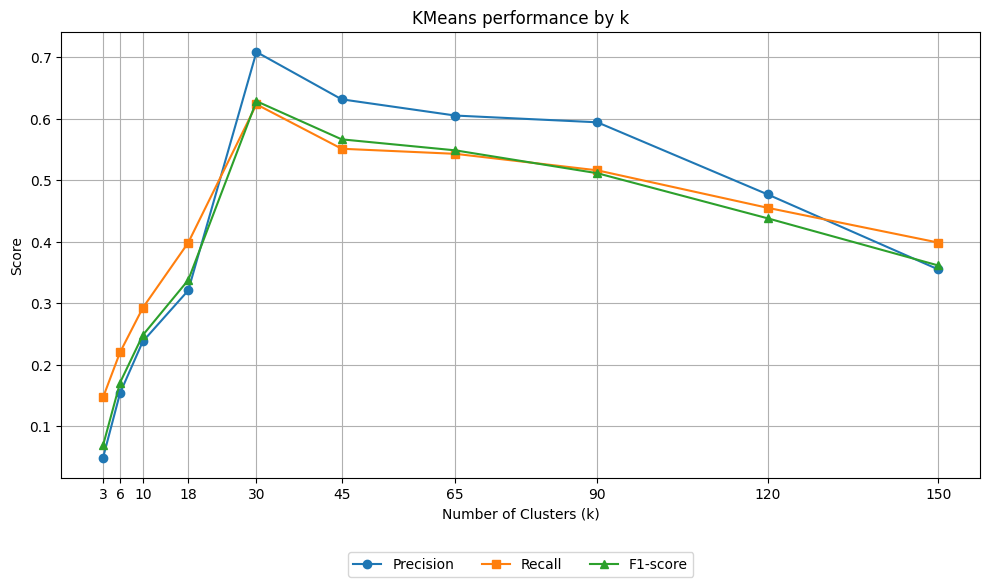

In [ ]:
import matplotlib.pyplot as plt

# Plot all three metrics
plt.figure(figsize=(10, 6))
plt.plot(k_values, [prec[k] for k in k_values], marker='o', label='Precision')
plt.plot(k_values, [rec[k] for k in k_values], marker='s', label='Recall')
plt.plot(k_values, [f1[k] for k in k_values], marker='^', label='F1-score')

# Axis labels and title
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.title("KMeans performance by k")
plt.xticks(k_values)  # Ensure all k values show on x-axis

# Legend below the plot
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.grid(True)
plt.tight_layout()

plt.savefig("kmeans_k_plot.pdf", bbox_inches="tight", dpi=300)
# Show plot
plt.show()


### HIERARCHICAL

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import classification_report

def run_hierarchical(n_clusters):
    name = 'hierarchical'
    clusterer = AgglomerativeClustering(n_clusters=n_clusters)
    cluster_labels = clusterer.fit_predict(X_red.loc[unclustered])
    cluster_labels = [c if c != -1 else c for c in cluster_labels]
    df_sample.loc[unclustered, name] = cluster_labels

    n_clusters = max(cluster_labels) + 1
    ordered_clusters = np.sort(df_sample[name].unique())
    n_clusters = len(ordered_clusters)

    summary = {}
    for j in tqdm(range(n_clusters)):
        summary[ordered_clusters[j]] = my_textrank(df_sample[df_sample[name] == ordered_clusters[j]])

    df_export = df_sample[df_sample.columns.drop(list(df_sample.filter(regex='U\d+')))]
    df_export_2 = df_testo[df_testo.QUESITO_CLEAN.isin(df_export.QUESITO_CLEAN)][[
        'ANNO', 'TIPO_PRESCRITTORE', 'COD_ATS_PRESCRITTORE_DESC', 'NUMERO',
        'QUESITO_CLEAN', 'QUESITO_DIAGNOSTICO'
    ]].merge(df_export, on='QUESITO_CLEAN', how='left', suffixes=('', '_exp'))

    df_labels['LABEL_FIXED'] = df_labels.LABEL
    df_labels.loc[(df_labels.LABEL.notna()) & (~df_labels.LABEL.isin(labels_to_keep)), 'LABEL_FIXED'] = 'altro'

    mapping_clusters_labels = {}

    for k, v in summary.items():
        label = get_mapping_qd(v)

        if label:
            mapping_clusters_labels[k] = label[0]
        else:
            mapping_clusters_labels[k] = 'altro'

    df_export_3 = df_export_2[df_export_2.QUESITO_DIAGNOSTICO.isin(
        df_labels[df_labels.LABEL.notna()].QUESITO_DIAGNOSTICO)]
    df_export_3 = df_export_3.merge(df_labels.loc[
        df_labels.LABEL_FIXED.notna(), ['QUESITO_DIAGNOSTICO', 'LABEL_FIXED']
    ], on='QUESITO_DIAGNOSTICO', how='left')

    df_export_3 = df_export_3.groupby(['QUESITO_CLEAN', 'QUESITO_DIAGNOSTICO', name, 'LABEL_FIXED'])['NUMERO'].sum().reset_index()
    df_export_3['LABEL_CLUSTER'] = df_export_3[name].map(mapping_clusters_labels)
    df_export_3['cluster_summary'] = df_export_3[name].map(lambda x: ';'.join(summary[x]))

    df_export_4 = df_export_3  # optionally filter out outliers

    report = classification_report(df_export_4.LABEL_FIXED, df_export_4.LABEL_CLUSTER, digits=4, output_dict=True)

    macro_precision = report['macro avg']['precision']
    macro_recall = report['macro avg']['recall']
    macro_f1 = report['macro avg']['f1-score']

    return macro_precision, macro_recall, macro_f1


In [ ]:
prec = {}
rec = {}
f1 = {}
k_values = [3, 6, 10, 18, 30, 45, 65, 90, 120, 150]
for k in tqdm(k_values):
  prec[k], rec[k], f1[k] = run_hierarchical(k)

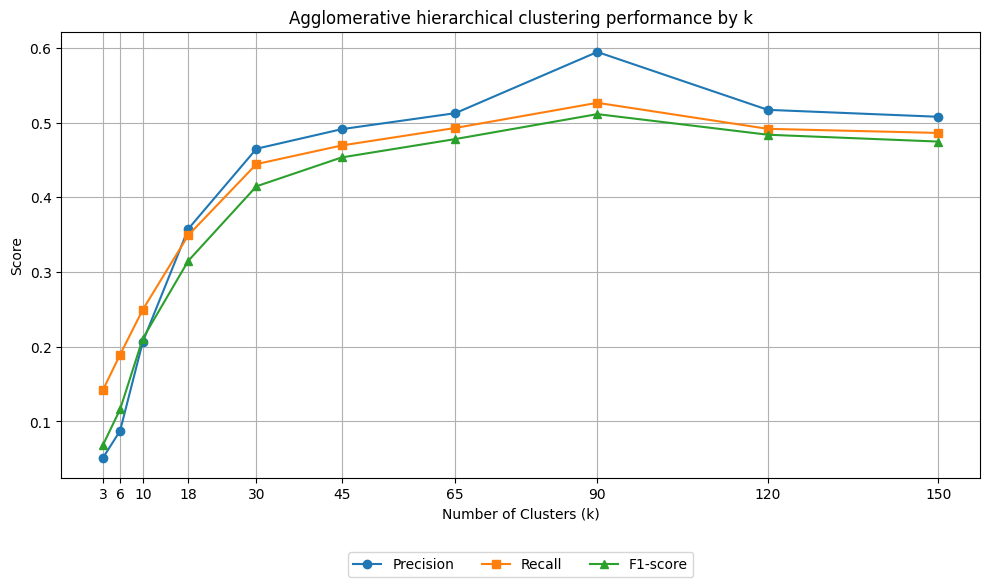

In [ ]:
import matplotlib.pyplot as plt

# Plot all three metrics
plt.figure(figsize=(10, 6))
plt.plot(k_values, [prec[k] for k in k_values], marker='o', label='Precision')
plt.plot(k_values, [rec[k] for k in k_values], marker='s', label='Recall')
plt.plot(k_values, [f1[k] for k in k_values], marker='^', label='F1-score')

# Axis labels and title
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.title("Agglomerative hierarchical clustering performance by k")
plt.xticks(k_values)  # Ensure all k values show on x-axis

# Legend below the plot
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.grid(True)
plt.tight_layout()

plt.savefig("hierarchical_k_plot.pdf", bbox_inches="tight", dpi=300)
# Show plot
plt.show()


### CLUSTER ALL

In [ ]:
i = 0
export_list = []
while i < len(df_quesiti):
  print(i)
  if i + 30000 < len(df_quesiti):
    df_sample = df_quesiti[i:i+30000]
  else:
    df_sample = df_quesiti[i:]

  X = df_sample.filter(regex=("U\d.*"))
  pca = PCA(n_components=50)
  X_red = pca.fit_transform(X)
  X_red = pd.DataFrame(X_red, index=X.index)
  name = 'umb_e3c_3'
  unclustered=df_sample.index
  min_cluster_size = 20
  n_clusters = 0
  distances = pairwise_distances(X_red.loc[unclustered], metric='cosine')
  clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, metric='precomputed', min_samples=1)#, cluster_selection_epsilon=0.00)
  cluster_labels = clusterer.fit_predict(distances)
  cluster_labels = [c+n_clusters if c!=-1 else c for c in cluster_labels]
  min_cluster_size //= 2
  df_sample.loc[unclustered, name] = cluster_labels
  unclustered = df_sample[df_sample[name] == -1].index

  ordered_clusters = np.sort(df_sample[name].unique())
  n_clusters = len(ordered_clusters)

  summary = {}
  for j in tqdm(range(n_clusters)):
    summary[ordered_clusters[j]] = my_textrank(df_sample[df_sample[name]==ordered_clusters[j]])

  mapping_clusters_labels = {}

  for k, v in summary.items():
      label = get_mapping_qd(v)

      if label:
          mapping_clusters_labels[k] = label[0]  # Take the best match
      else:
          mapping_clusters_labels[k] = 'altro'

  df_export = df_sample[df_sample.columns.drop(list(df_sample.filter(regex='U\d+')))]
  df_export_2 = df_testo[df_testo.QUESITO_CLEAN.isin(df_export.QUESITO_CLEAN)][['ANNO', 'TIPO_PRESCRITTORE', 'COD_ATS_PRESCRITTORE_DESC', 'NUMERO', 'QUESITO_CLEAN', 'QUESITO_DIAGNOSTICO']].merge(df_export, on='QUESITO_CLEAN', how='left', suffixes=('', '_exp'))

  df_export_3 = df_export_2
  df_export_3['LABEL_CLUSTER'] = df_export_3[name].map(mapping_clusters_labels)
  df_export_3['cluster_summary'] = df_export_3[name].map(lambda x: ';'.join(summary[x]))
  df_export_3.loc[df_export_3[name] == -1, 'LABEL_CLUSTER'] = 'altro'


  df_export_3['APPR'] = df_export_3.LABEL_CLUSTER.apply(lambda x: get_appr_class(x))
  #export_list.append(df_export_3.copy())
  export_list.append(df_export_3.groupby(['ANNO', 'TIPO_PRESCRITTORE', 'COD_ATS_PRESCRITTORE_DESC', 'LABEL_CLUSTER', 'APPR',])['NUMERO'].sum())#.to_excel('df_export_3_' + str(i) + '.xlsx')
  i += 30000



In [ ]:
df_export_summ = pd.concat([e.reset_index() for e in export_list])

In [ ]:
df_export_summ.groupby(['ANNO', 'TIPO_PRESCRITTORE', 'COD_ATS_PRESCRITTORE_DESC', 'APPR', 'LABEL_CLUSTER'])['NUMERO'].sum().reset_index()

In [ ]:
df_export_summ.to_excel('summary_ecd.xlsx')

In [ ]:
df_export_summ = pd.read_excel('summary_ecd.xlsx')

In [ ]:
# Group by 'LABEL_CLUSTER' and 'APPR', sum 'NUMERO', and calculate the percentage.
grouped_df = df_export_summ.groupby(['LABEL_CLUSTER', 'APPR'])['NUMERO'].sum().reset_index()
total_sum = grouped_df['NUMERO'].sum()
grouped_df['Percentage'] = (grouped_df['NUMERO'] / total_sum) * 100
grouped_df.sort_values(by='Percentage', ascending=False)

In [ ]:
grouped_df.sort_values(by='Percentage', ascending=False).to_excel('summary_ecd_top.xlsx')

In [ ]:
df_export_summ.groupby(['LABEL_CLUSTER', 'APPR'])['NUMERO'].sum().reset_index().sort_values(by='NUMERO', ascending=False)

In [ ]:
ats_mapping = # OMISSIS

df_export_summ ['ATS_Coded'] = df_export_summ ['COD_ATS_PRESCRITTORE_DESC'].map(ats_mapping)

In [ ]:
df_export_summ.groupby(['ATS_Coded', 'LABEL_CLUSTER'])['NUMERO'].sum().reset_index().sort_values(by='NUMERO', ascending=False)

## LDA

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary

# Prepare data
processed_texts = df_sample.QUESITO_CLEAN.fillna('').to_list()

# Vectorization
vectorizer = CountVectorizer()
document_term_matrix = vectorizer.fit_transform(processed_texts)
terms = vectorizer.get_feature_names_out()

# Prepare data for coherence calculation
tokenized_texts = [text.split() for text in processed_texts]
id2word = Dictionary(tokenized_texts)
corpus = [id2word.doc2bow(text) for text in tokenized_texts]

# Function to compute coherence score
def compute_coherence(lda_model, corpus, dictionary, texts):
    topics = [[terms[word_id] for word_id in topic.argsort()[-10:]]
              for topic in lda_model.components_]
    cm = CoherenceModel(topics=topics, texts=texts, corpus=corpus, dictionary=dictionary, coherence='c_v')
    return cm.get_coherence()

# Explore coherence for varying number of topics
coherence_scores = []
topic_range = range(2, 51)

for num_topics in tqdm(topic_range):
    lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
    lda.fit(document_term_matrix)
    coherence = compute_coherence(lda, corpus, id2word, tokenized_texts)
    coherence_scores.append(coherence)
    print(f"Num Topics: {num_topics}, Coherence Score: {coherence:.4f}")

# Plot coherence scores
plt.figure(figsize=(10, 6))
plt.plot(topic_range, coherence_scores, marker='o', linestyle='-', color='b')
plt.title("Coherence Score vs. Number of Topics")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.grid()
plt.show()


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

processed_texts = df_sample.QUESITO_CLEAN.fillna('').to_list()


# Vectorization
vectorizer = CountVectorizer()
document_term_matrix = vectorizer.fit_transform(processed_texts)

# LDA model
num_topics = 13
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda.fit(document_term_matrix)

doc_topic_matrix = lda.transform(document_term_matrix)

# Displaying topics
def display_topics(model, feature_names, num_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}: ")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-num_top_words - 1:-1]]))

num_top_words = 5
feature_names = vectorizer.get_feature_names_out()
print("Topics identified by LDA:")
display_topics(lda, feature_names, num_top_words)

# Assigning texts to topics
doc_topic_matrix = lda.transform(document_term_matrix)
text_topic_assignments = doc_topic_matrix.argmax(axis=1)

In [ ]:
name = 'LDA'
df_sample[name] = text_topic_assignments
n_clusters = max(text_topic_assignments)+1
ordered_clusters = np.sort(df_sample[name].unique())

In [ ]:
summary = {}
for j in tqdm(range(n_clusters)):
  summary[ordered_clusters[j]] = my_textrank(df_sample[df_sample[name]==ordered_clusters[j]])

In [ ]:
df_export = df_sample[df_sample.columns.drop(list(df_sample.filter(regex='U\d+')))]

In [ ]:
df_export_2 = df_testo[df_testo.QUESITO_CLEAN.isin(df_export.QUESITO_CLEAN)][['ANNO', 'TIPO_PRESCRITTORE', 'COD_ATS_PRESCRITTORE_DESC', 'NUMERO', 'QUESITO_CLEAN', 'QUESITO_DIAGNOSTICO']].merge(df_export, on='QUESITO_CLEAN', how='left', suffixes=('', '_exp'))

In [ ]:
df_labels['LABEL_FIXED'] = df_labels.LABEL
df_labels.loc[(df_labels.LABEL.notna())&(~df_labels.LABEL.isin(labels_to_keep)),'LABEL_FIXED'] = 'altro'

## WORD2VEC

### UTILS

In [ ]:
from nltk.tokenize import sent_tokenize
stop_words = nltk.corpus.stopwords.words('italian')
stop_words = [s for s in stop_words if s!='nei']

In [ ]:
import re

def clean_word2vec(string):

  # removing everything except a-z english letters
  regex = re.compile('[^a-zA-Z]')
  temp_string = regex.sub(' ', string)

  # removing extra spaces
  clean_string = re.sub(' +', ' ', temp_string).lower()

  return clean_string

In [ ]:
def clean_word2vec_sentence(s):
  if pd.isna(s):
    return None
  s = clean_word2vec(s.lower())
  stop_free = ' '.join([w for w in s.split() if w not in stop_words])
  #spacy_doc = nlp(stop_free)
  #temp_sent = [token.lemma_ for token in spacy_doc]
  #return " ".join(temp_sent)
  return stop_free

### COMPUTE EMBEDDINGS

In [ ]:
from gensim.models import Word2Vec
w2v_path = '.../word2vec_ft_3.obj'
#with open(w2v_path, 'rb') as fp:
#  word2vec_model = pickle.load(fp)
word2vec_model = Word2Vec.load(w2v_path)

In [ ]:
from gensim.models import KeyedVectors
word2vec_model = KeyedVectors.load(".../W2V.kv")

In [ ]:
def compute_word2vec_vector(s, model):
  s = clean_word2vec_sentence(s)
  #print('string cleaned:', s)
  words = s.split(' ')
  word_vectors = []
  for w in words:
    #if w in model.wv:
    if w in model:
      #w_vector = model.wv.get_vector(w)
      #w_vector = model.wv[w]
      w_vector = model[w]
    else:
      w_vector = np.zeros(300)
    word_vectors.append(w_vector)
  return np.mean(word_vectors, axis=0)

In [ ]:
df_testo = df

In [ ]:
df_testo['W2V_base'] = df_testo['QUESITO_DIAGNOSTICO'].progress_apply(lambda x: compute_word2vec_vector(x, word2vec_model))

In [ ]:
w2v_dict = {str(key): dict(enumerate(emb)) for (key, emb) in dict(enumerate(df_testo['W2V_base'])).items()}
w2v_df = pd.DataFrame.from_dict(w2v_dict, orient='index')
column_remapping = {i:'W'+str(i) for i in range(len(w2v_df.columns))}
w2v_df.rename(columns=column_remapping, inplace=True)

In [ ]:
df_testo = df_testo[df_testo.columns.drop(list(df_testo.filter(regex='W\d+')))]
df_testo.drop('level_0', axis=1, inplace=True, errors='ignore')
df_testo = pd.concat([df_testo.reset_index(), w2v_df.reset_index()], axis=1)

## DIRECT EMBEDDINGS MATCH

In [ ]:
df_emb['LABEL_FIXED'] = df_emb.LABEL
df_emb.loc[(df_emb.LABEL.notna())&(~df_emb.LABEL.isin(labels_to_keep)),'LABEL_FIXED'] = 'altro'

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity

name = 'direct_emb_match'

# Step 1: DataFrame with embeddings
text_embeddings = df_emb[[f'U{i}' for i in range(768)]].values  # shape: (n_texts, 768)

# Step 2: Load UmBERTo model and tokenizer
tokenizer = tokenizer
model = umberto

# Step 3: Encode labels
def encode_labels(labels):
    inputs = tokenizer(labels, padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    embeddings = outputs.last_hidden_state.mean(dim=1)  # average over tokens
    return embeddings.cpu().numpy()  # shape: (n_labels, hidden_size)

label_list = labels_to_keep.copy()
label_list.remove('altro')
label_embeddings = encode_labels(label_list)  # shape: (n_labels, 768)

# Step 4: Calculate cosine similarity
similarities = cosine_similarity(text_embeddings, label_embeddings)  # shape: (n_texts, n_labels)

# Step 5: Assign most similar label or a default if similarity is too low
threshold = 0.6
default_label = "altro"

assigned_labels = []
for sim_row in similarities:
    max_sim = sim_row.max()
    if max_sim < threshold:
        assigned_labels.append(default_label)
    else:
        assigned_labels.append(label_list[sim_row.argmax()])


df_emb[name] = assigned_labels

## CLUSTER ANALYSIS

In [ ]:
i += 1
gruppo = df_testo[df_testo[name]==i][['QUESITO_CLEAN', 'NUMERO']]
print(i)
print('GROUP DIMENSION =', sum(gruppo.NUMERO))
print(gruppo[:50])

In [ ]:
df_clustered = df_testo[df_testo[name]!=-1]

# PAPER PLOTS

## STATS

In [ ]:
df_colon = pd.read_excel('df_colon_endo_clustered_def.xlsx')

In [ ]:
quesito_sums = df_colon.groupby('QUESITO_DIAGNOSTICO')['NUMERO'].sum()

# Count the number of values where the sum of 'NUMERO' is > 1
count = len(quesito_sums[quesito_sums > 1])

print(f"Number of QUESITO_DIAGNOSTICO with NUMERO sum > 1: {count / df_colon.QUESITO_DIAGNOSTICO.nunique()}")

In [ ]:
df_export_summ = df_colon.groupby(['ANNO', 'TIPO_PRESCRITTORE', 'COD_ATS_PRESCRITTORE_DESC', 'DIAGNOSI_FIXED', 'APPR',])['NUMERO'].sum().reset_index()
df_export_summ

In [ ]:
df_export_summ.to_excel('summary_colon_clustered.xlsx')

In [ ]:
df_export_summ = pd.read_excel('summary_colon_clustered.xlsx')

In [ ]:
# Group by 'LABEL_CLUSTER' and 'APPR', sum 'NUMERO', and calculate the percentage.
grouped_df_colon = df_export_summ.groupby(['LABEL_CLUSTER', 'APPR'])['NUMERO'].sum().reset_index()
total_sum = grouped_df_colon['NUMERO'].sum()
grouped_df_colon['Percentage'] = (grouped_df_colon['NUMERO'] / total_sum) * 100
grouped_df_colon.sort_values(by='Percentage', ascending=False)

In [ ]:
grouped_df_colon.sort_values(by='Percentage', ascending=False).to_excel('summary_colon_top.xlsx')

In [ ]:
ats_mapping = # OMISSIS
df_export_summ['ATS_Coded'] = df_export_summ['COD_ATS_PRESCRITTORE_DESC'].map(ats_mapping)

In [ ]:
df_export_summ.groupby(['ATS_Coded', 'LABEL_CLUSTER'])['NUMERO'].sum().reset_index().sort_values(by='NUMERO', ascending=False)

## SINGLE STRATIFIED PLOT

<ipython-input-174-11b5467d4bf6>:131: UserWarning: The figure layout has changed to tight
  fig.tight_layout(h_pad=5)


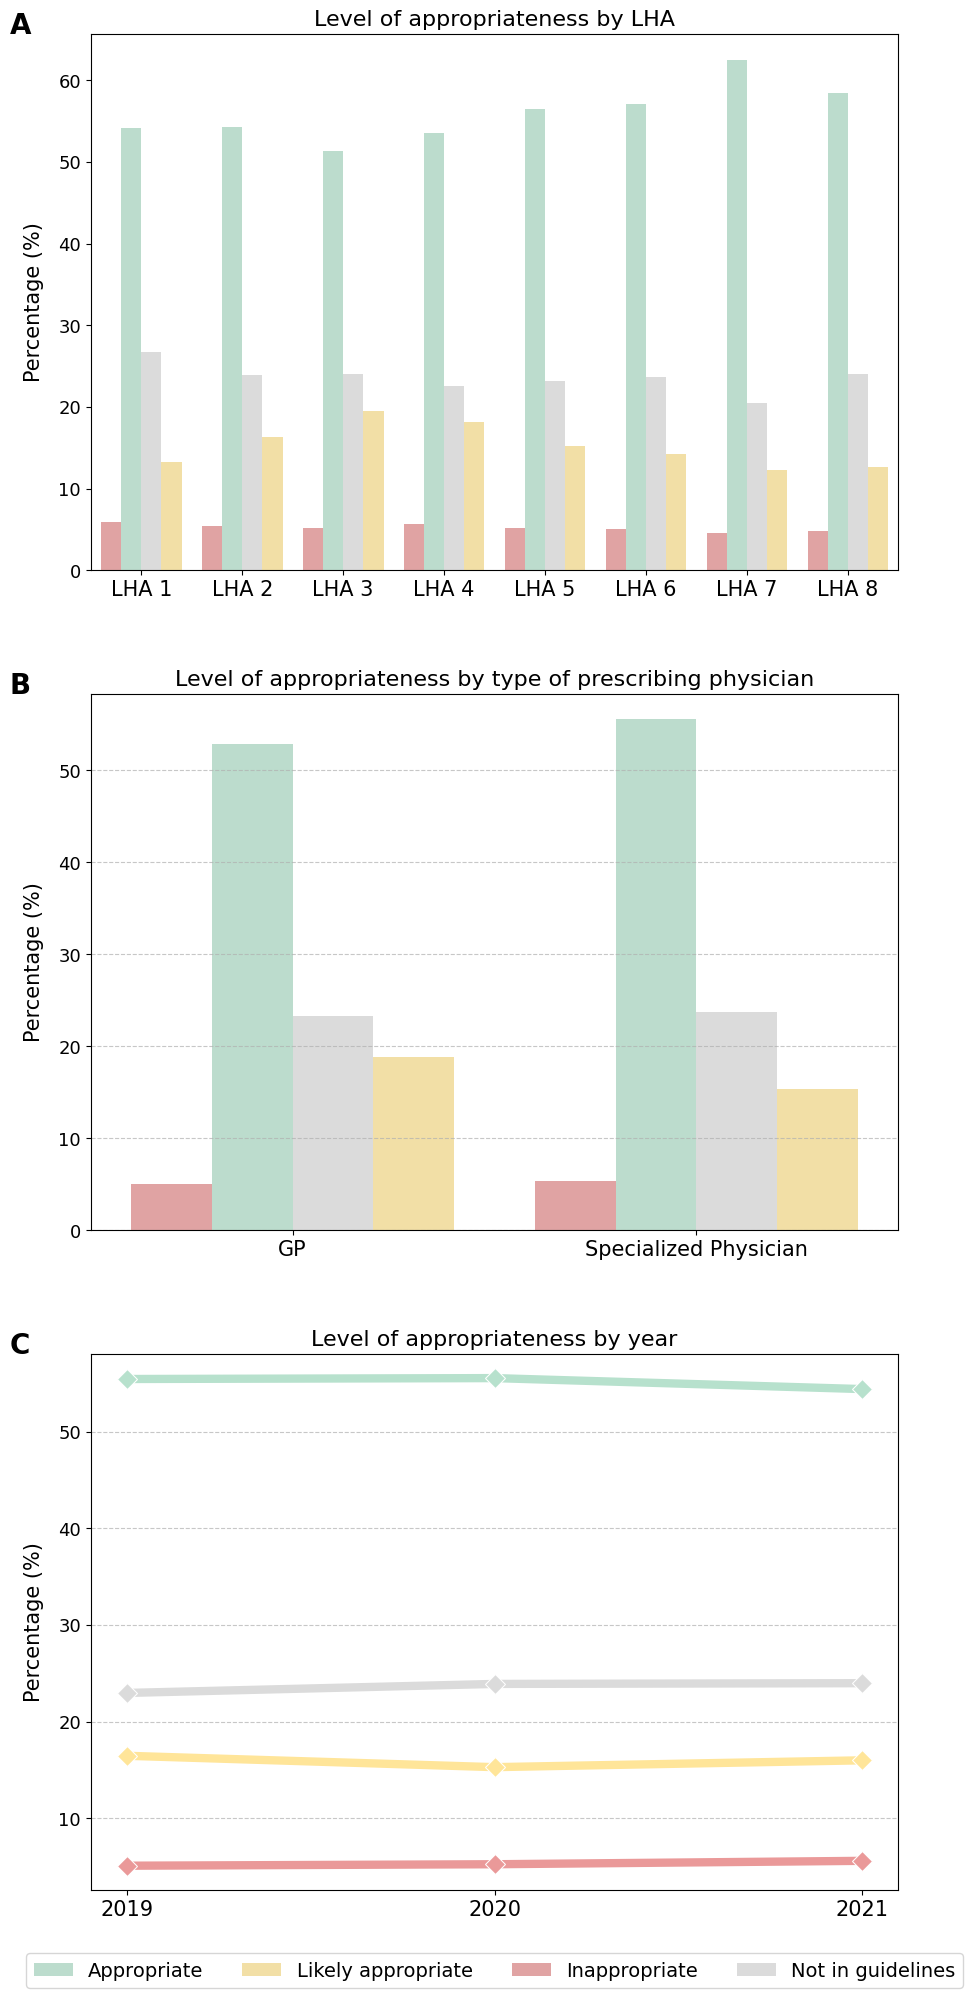

In [ ]:
import seaborn as sns
%matplotlib inline
from matplotlib.ticker import MaxNLocator

# Create the plot
fig, axs = plt.subplots(3, 1, figsize=(10, 20), constrained_layout=True)

df = df_export_summ.copy()

# Calculate the percentage for each APPR within each ATS
df['PERCENT'] = df.groupby('ATS_Coded')['NUMERO'].transform(lambda x: x / x.sum() * 100)

df = df.groupby(['ATS_Coded', 'APPR'])['PERCENT'].sum().reset_index()

# Define colors for each APPR value
colors = {0: '#ea9999', 1: '#b7e1cd', 2: '#dbdbdb', 3: '#ffe599'}

ax = axs[0]
sns.barplot(
    data=df,
    x='ATS_Coded',
    y='PERCENT',
    hue='APPR',
    palette=colors,
    errorbar=None,
    ax=ax
);

# Add labels and title
ax.set_title('Level of appropriateness by LHA', fontsize=16)
ax.set_ylabel('Percentage (%)', fontsize=15, labelpad=10)
ax.set_xlabel('', fontsize=12)
ax.tick_params(axis='y', which='major', labelsize=13)
ax.tick_params(axis='x', which='major', labelsize=15)
ax.legend_.remove()

extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
#fig.savefig('vai_ats.pdf', bbox_inches=extent.expanded(1.1, 1.2))

df = df_export_summ.copy()

df['PERCENT'] = df.groupby('TIPO_PRESCRITTORE')['NUMERO'].transform(lambda x: x / x.sum() * 100)

df = df.groupby(['TIPO_PRESCRITTORE', 'APPR'])['PERCENT'].sum().reset_index()

df['TIPO_PRESCRITTORE'] = df['TIPO_PRESCRITTORE'].map({'ALTRA TIPOLOGIA': 'GP', 'MEDICINA GENERALE': 'Specialized Physician'})

# Define colors for each APPR value
colors = {0: '#ea9999', 1: '#b7e1cd', 2: '#dbdbdb', 3: '#ffe599'}

ax=axs[1]
# Create the plot
sns.barplot(
    data=df,
    x='TIPO_PRESCRITTORE',
    y='PERCENT',
    hue='APPR',
    palette=colors,
    errorbar=None,
    ax=ax,
    order=['GP', 'Specialized Physician']
)

# Add labels and title
ax.set_title('Level of appropriateness by type of prescribing physician', fontsize=16)
ax.set_ylabel('Percentage (%)', fontsize=15, labelpad=10)
ax.set_xlabel('', fontsize=12)
ax.tick_params(axis='y', which='major', labelsize=13)
ax.tick_params(axis='x', which='major', labelsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.get_legend().remove()


df = df_export_summ.copy()

# Calculate the percentage for each APPR within each ATS
df['PERCENT'] = df.groupby('ANNO')['NUMERO'].transform(lambda x: x / x.sum() * 100)

df = df.groupby(['ANNO', 'APPR'])['PERCENT'].sum().reset_index()

ax=axs[2]
# Create the plot
sns.lineplot(
    data=df,
    x='ANNO',
    y='PERCENT',
    hue='APPR',
    palette=colors,
    errorbar=None,
    ax=ax,
    marker='D',
    linewidth=6,
    markersize=10
)

# Add labels and title
ax.set_title('Level of appropriateness by year', fontsize=16)
ax.set_ylabel('Percentage (%)', fontsize=15, labelpad=10)
ax.set_xlabel('', fontsize=12)
ax.tick_params(axis='y', which='major', labelsize=13)
ax.tick_params(axis='x', which='major', labelsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# Custom labels for the legend
custom_labels = {0: 'Inappropriate', 1: 'Appropriate', 2: 'Not in guidelines', 3: 'Likely appropriate'}
# Remove the default legend
ax.get_legend().remove()
# Create a new custom legend
handles, labels = axs[1].get_legend_handles_labels()  # Get current legend handles
handles = [handles[1], handles[3], handles[0], handles[2]]
labels = ['1', '3', '0', '2']
# Map the custom labels
custom_labels_list = [custom_labels[int(label)] for label in labels]
ax.legend(handles=handles, labels=custom_labels_list, title='', fontsize=14, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())

import string
axs_flat = axs.flat
for n, ax in enumerate(axs_flat):
    ax.text(-0.1, 1, string.ascii_uppercase[n], transform=ax.transAxes,
            size=20, weight='bold')

fig.tight_layout(h_pad=5)
fig.savefig('summary_colon_grouped_suppl.pdf')
fig.show()

## STRATIFIED PLOT ECD - COLON

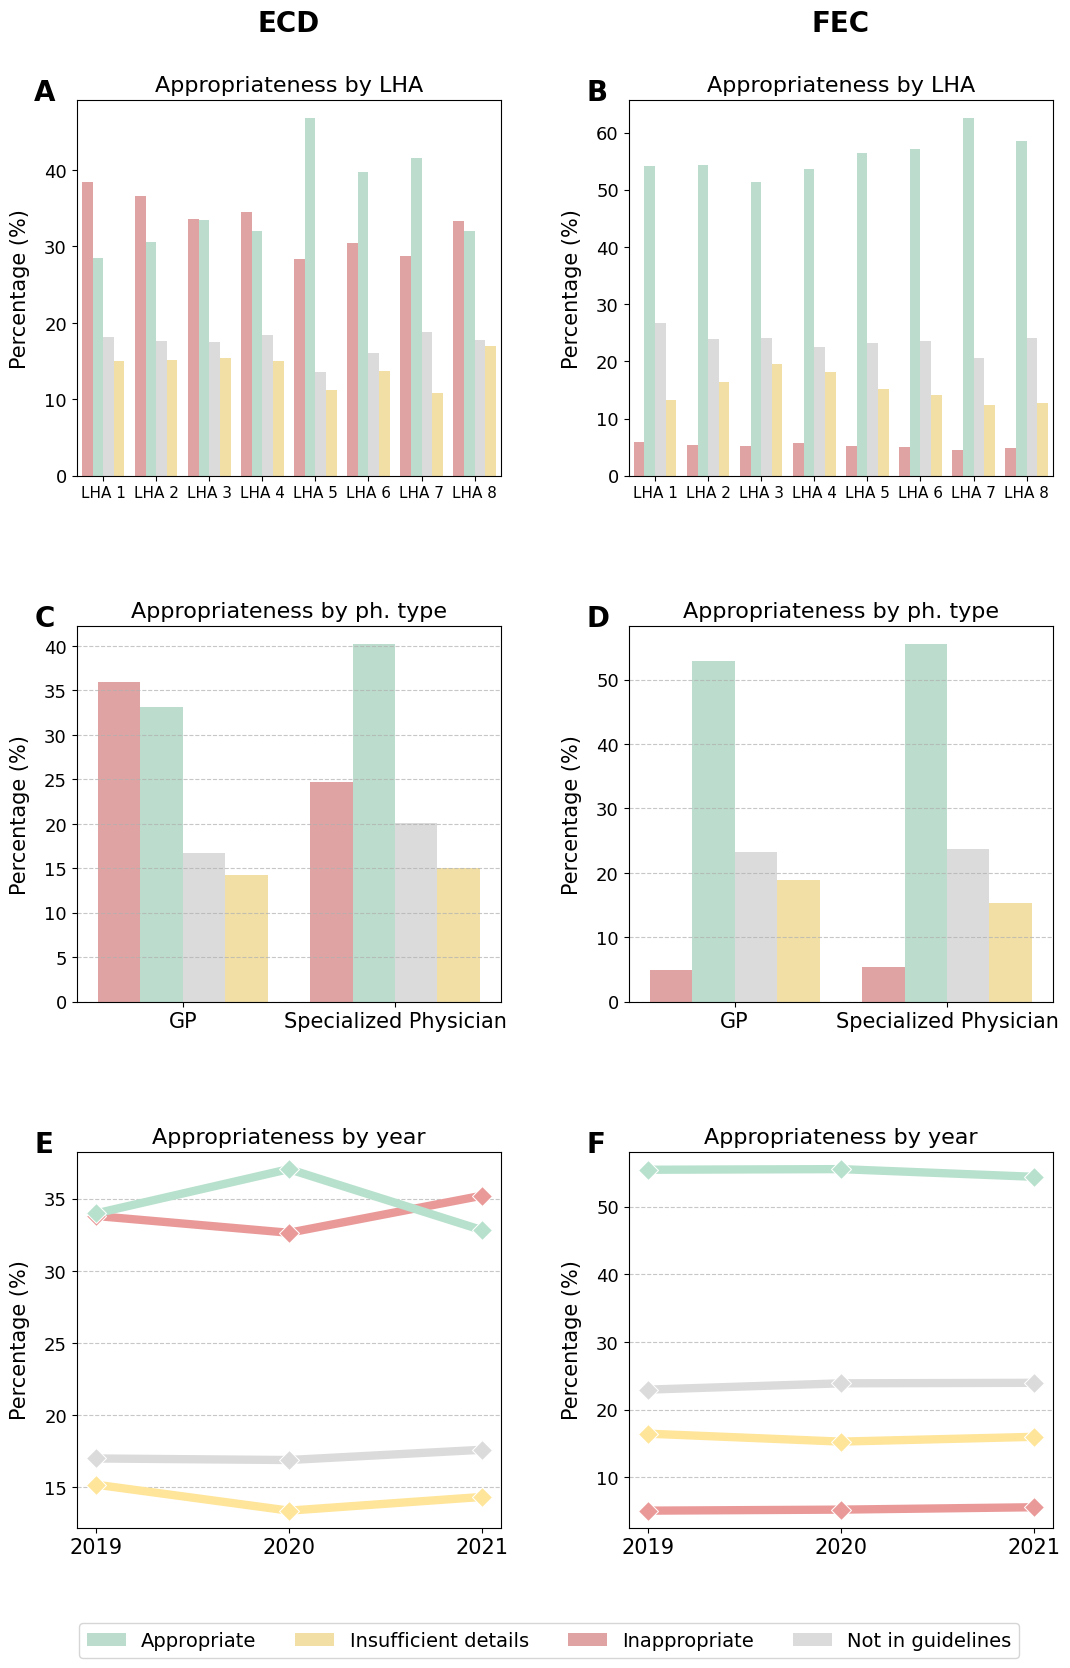

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.ticker import MaxNLocator

# Create the plot
fig, axs = plt.subplots(3, 2, figsize=(12.60, 17.20), gridspec_kw={'wspace': 0.3, 'hspace': 0.4})

axs = axs.flat

### ATS ECD

df_ecd = df_export_summ.copy()

# Calculate the percentage for each APPR within each ATS
df_ecd['PERCENT'] = df_ecd.groupby('ATS_Coded')['NUMERO'].transform(lambda x: x / x.sum() * 100)
df_ecd = df_ecd.groupby(['ATS_Coded', 'APPR'])['PERCENT'].sum().reset_index()

# Define colors for each APPR value
colors = {0: '#ea9999', 1: '#b7e1cd', 2: '#dbdbdb', 3: '#ffe599'}

ax = axs[0]
sns.barplot(
    data=df_ecd,
    x='ATS_Coded',
    y='PERCENT',
    hue='APPR',
    palette=colors,
    errorbar=None,
    ax=ax
);

# Add labels and title
ax.set_title('Appropriateness by LHA', fontsize=16)
ax.set_ylabel('Percentage (%)', fontsize=15, labelpad=10)
ax.set_xlabel('', fontsize=12)
ax.tick_params(axis='y', which='major', labelsize=13)
ax.tick_params(axis='x', which='major', labelsize=11)
ax.legend_.remove()

extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
#fig.savefig('vai_ats.pdf', bbox_inches=extent.expanded(1.1, 1.2))

### ATS COLON
df_colon = df_export_summ_colon.copy()
# Calculate the percentage for each APPR within each ATS
df_colon['PERCENT'] = df_colon.groupby('ATS_Coded')['NUMERO'].transform(lambda x: x / x.sum() * 100)
df_colon = df_colon.groupby(['ATS_Coded', 'APPR'])['PERCENT'].sum().reset_index()

# Define colors for each APPR value
colors = {0: '#ea9999', 1: '#b7e1cd', 2: '#dbdbdb', 3: '#ffe599'}

ax = axs[1]
sns.barplot(
    data=df_colon,
    x='ATS_Coded',
    y='PERCENT',
    hue='APPR',
    palette=colors,
    errorbar=None,
    ax=ax
);

# Add labels and title
ax.set_title('Appropriateness by LHA', fontsize=16)
ax.set_ylabel('Percentage (%)', fontsize=15, labelpad=10)
ax.set_xlabel('', fontsize=12)
ax.tick_params(axis='y', which='major', labelsize=13)
ax.tick_params(axis='x', which='major', labelsize=11)
ax.legend_.remove()

### PHYSICIAN ECD
df = df_export_summ.copy()

df['PERCENT'] = df.groupby('TIPO_PRESCRITTORE')['NUMERO'].transform(lambda x: x / x.sum() * 100)
df = df.groupby(['TIPO_PRESCRITTORE', 'APPR'])['PERCENT'].sum().reset_index()
df['TIPO_PRESCRITTORE'] = df['TIPO_PRESCRITTORE'].map({'ALTRA TIPOLOGIA': 'Specialized Physician', 'MEDICINA GENERALE': 'GP'})

# Define colors for each APPR value
colors = {0: '#ea9999', 1: '#b7e1cd', 2: '#dbdbdb', 3: '#ffe599'}

ax=axs[2]
# Create the plot
sns.barplot(
    data=df,
    x='TIPO_PRESCRITTORE',
    y='PERCENT',
    hue='APPR',
    palette=colors,
    errorbar=None,
    ax=ax,
    order=['GP', 'Specialized Physician']
)

# Add labels and title
ax.set_title('Appropriateness by ph. type', fontsize=16)
ax.set_ylabel('Percentage (%)', fontsize=15, labelpad=10)
ax.set_xlabel('', fontsize=12)
ax.tick_params(axis='y', which='major', labelsize=13)
ax.tick_params(axis='x', which='major', labelsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.get_legend().remove()

### PHYSICIAN COLON
df = df_export_summ_colon.copy()

df['PERCENT'] = df.groupby('TIPO_PRESCRITTORE')['NUMERO'].transform(lambda x: x / x.sum() * 100)
df = df.groupby(['TIPO_PRESCRITTORE', 'APPR'])['PERCENT'].sum().reset_index()
df['TIPO_PRESCRITTORE'] = df['TIPO_PRESCRITTORE'].map({'ALTRA TIPOLOGIA': 'GP', 'MEDICINA GENERALE': 'Specialized Physician'})

# Define colors for each APPR value
colors = {0: '#ea9999', 1: '#b7e1cd', 2: '#dbdbdb', 3: '#ffe599'}

ax=axs[3]
# Create the plot
sns.barplot(
    data=df,
    x='TIPO_PRESCRITTORE',
    y='PERCENT',
    hue='APPR',
    palette=colors,
    errorbar=None,
    ax=ax,
    order=['GP', 'Specialized Physician']
)

# Add labels and title
ax.set_title('Appropriateness by ph. type', fontsize=16)
ax.set_ylabel('Percentage (%)', fontsize=15, labelpad=10)
ax.set_xlabel('', fontsize=12)
ax.tick_params(axis='y', which='major', labelsize=13)
ax.tick_params(axis='x', which='major', labelsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.get_legend().remove()

### YEAR ECD

df= df_export_summ.copy()

df['PERCENT'] = df.groupby('ANNO')['NUMERO'].transform(lambda x: x / x.sum() * 100)

df = df.groupby(['ANNO', 'APPR'])['PERCENT'].sum().reset_index()

ax=axs[4]
# Create the plot
sns.lineplot(
    data=df,
    x='ANNO',
    y='PERCENT',
    hue='APPR',
    palette=colors,
    errorbar=None,
    ax=ax,
    marker='D',
    linewidth=6,
    markersize=10
)

# Add labels and title
ax.set_title('Appropriateness by year', fontsize=16)
ax.set_ylabel('Percentage (%)', fontsize=15, labelpad=10)
ax.set_xlabel('', fontsize=12)
ax.tick_params(axis='y', which='major', labelsize=13)
ax.tick_params(axis='x', which='major', labelsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.get_legend().remove()

### YEAR COLON

df= df_export_summ_colon.copy()

df['PERCENT'] = df.groupby('ANNO')['NUMERO'].transform(lambda x: x / x.sum() * 100)

df = df.groupby(['ANNO', 'APPR'])['PERCENT'].sum().reset_index()

ax=axs[5]
# Create the plot
sns.lineplot(
    data=df,
    x='ANNO',
    y='PERCENT',
    hue='APPR',
    palette=colors,
    errorbar=None,
    ax=ax,
    marker='D',
    linewidth=6,
    markersize=10
)

# Add labels and title
ax.set_title('Appropriateness by year', fontsize=16)
ax.set_ylabel('Percentage (%)', fontsize=15, labelpad=10)
ax.set_xlabel('', fontsize=12)
ax.tick_params(axis='y', which='major', labelsize=13)
ax.tick_params(axis='x', which='major', labelsize=15)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# Custom labels for the legend
custom_labels = {0: 'Inappropriate', 1: 'Appropriate', 2: 'Not in guidelines', 3: 'Insufficient details'}
# Remove the default legend
ax.get_legend().remove()
# Create a new custom legend
handles, labels = axs[1].get_legend_handles_labels()  # Get current legend handles
handles = [handles[1], handles[3], handles[0], handles[2]]
labels = ['1', '3', '0', '2']
# Map the custom labels
custom_labels_list = [custom_labels[int(label)] for label in labels]
fig.legend(handles=handles, labels=custom_labels_list, title='', fontsize=14, loc='upper center', bbox_to_anchor=(0.5, 0.00), ncol=4)



import string
axs_flat = axs
for n, ax in enumerate(axs_flat):
    ax.text(-0.1, 1, string.ascii_uppercase[n], transform=ax.transAxes,
            size=20, weight='bold')

# Add column titles
column_titles = ['ECD', 'FEC']
for col, title in enumerate(column_titles):
    # Set the title for each column
    column_center = (axs[col].get_position().x0 + axs[col].get_position().x1) / 2
    fig.text(
        x=column_center,  # Adjust horizontally based on the number of columns
        y=0.92,  # Position slightly above the subplots
        s=title,
        ha='center',
        fontsize=20,
        fontweight='bold'
    )

#fig.tight_layout(h_pad=5, rect=[0, 0.05, 1, 1])
fig.subplots_adjust(bottom=0.05)
#fig.subplots_adjust(top=0.05)
#fig.savefig('summary_appr_colon_ecd.pdf', bbox_inches='tight')
fig.show()
# Show plot
#fig.tight_layout()
#ax.savefig('vai_ats.pdf')
# fig.show()

In [ ]:
fig.savefig('summary_appr_colon_ecd_a5.pdf', bbox_inches='tight')

# EMBEDDINGS PLOT

## VAI

In [ ]:
df_labels = pd.read_excel('df_export_ecd_clustered.xlsx')
df_labels = df_labels[~df_labels.LABEL.isna()]

In [ ]:
vai_labels_map = {'insufficienza venosa': 'Venous insufficiency',
                                                 'altro': 'Other',
                                                 'trombosi': 'Thrombosis',
                                                 'tromboflebitis': 'Tromboplhebitis',
                                                 'vasculopatia': 'Vasculopathy',
                                                 'edema': 'Edema',
                                                 'dolore': 'Pain',
                                                 'ulcera': 'Ulcer',
                                                 'varici': 'Varices',
                                                 'varici intervento': 'Varices surgery',
                                                 'safenectomia': 'Saphenectomy',
                                                 'parestesie': 'Paresthesis',
                                                 'claudicatio': 'Claudication',
                                                }

In [ ]:
df_labels['LABEL'] = df_labels['LABEL'].replace(vai_labels_map)

In [ ]:
len(df_labels)

In [ ]:
df_testo_ecd = pd.read_csv('df_testo_umberto_ecd.csv', index_col=0)

In [ ]:
df_emb = df_testo_ecd[df_testo_ecd.QUESITO_DIAGNOSTICO.isin(df_labels.QUESITO_DIAGNOSTICO)]

In [ ]:
df_emb['LABEL'] = df_emb.QUESITO_DIAGNOSTICO.map(df_labels.set_index('QUESITO_DIAGNOSTICO').LABEL)

In [ ]:
# Count occurrences of each label
label_counts = df_emb.drop_duplicates(subset='QUESITO_DIAGNOSTICO')['LABEL'].value_counts()

#keep = ['claudicatio', 'dolore', 'insufficienza venosa', 'edema', 'parestesie', 'safenectomia', 'tromboflebite', 'trombosi', 'ulcera', 'varici intervento', 'vasculopatia', 'altro']
keep = ['Venous insufficiency','Other','Thrombosis','Tromboplhebitis','Vasculopathy','Edema','Pain','Ulcer','Varices','Varices surgery','Saphenectomy', 'Paresthesis','Claudication',]

# Create LABEL_PLOT column
df_emb['LABEL_PLOT'] = df_emb['LABEL'].apply(
    lambda x: x if x in keep else 'Other'
)

label_counts = df_emb.drop_duplicates(subset='QUESITO_DIAGNOSTICO')['LABEL_PLOT'].value_counts()

In [ ]:
label_counts.sum()

In [ ]:
pip install colorcet

Text(-0.1, 1, 'A')

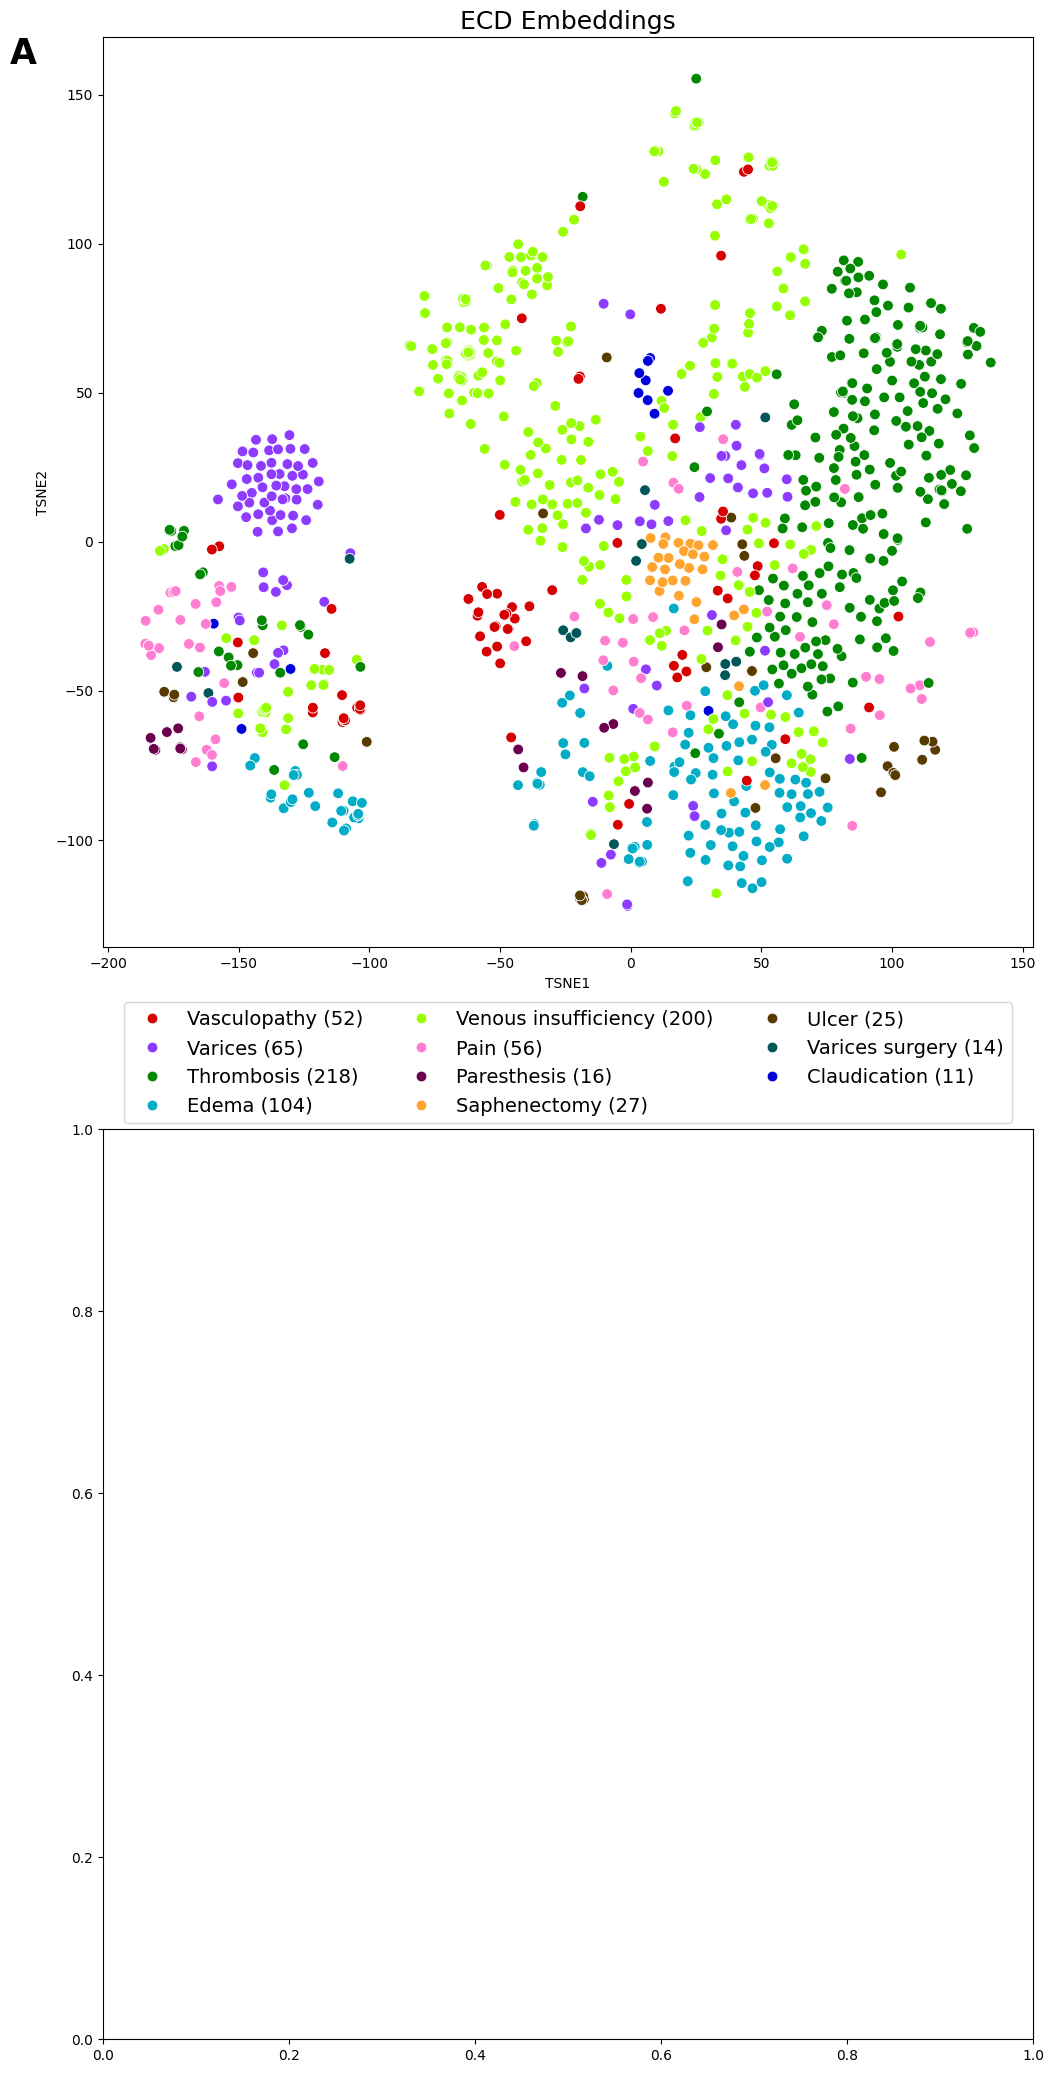

In [ ]:
import pandas as pd
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
import colorcet as cc

# Extract embeddings and labels
df_plot = df_emb[df_emb.LABEL_PLOT != 'Other']
embedding_columns = [f'U{i}' for i in range(768)]
X = df_plot[embedding_columns].values
#X = normalize(df_emb[embedding_columns], norm='l2')
labels = df_plot['LABEL_PLOT'].astype(str)  # Ensure LABEL is a string for clear legends

# Create a new column with labels + counts
labels_with_counts = labels.apply(lambda x: f"{x} ({label_counts[x]})")

# Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=50, max_iter=2000)
X_2d = tsne.fit_transform(X)
X_2d = X_2d + np.random.normal(scale=0.5, size=X_2d.shape)

# Create a DataFrame for plotting
tsne_df = pd.DataFrame({
    'TSNE1': X_2d[:, 0],
    'TSNE2': X_2d[:, 1],
    'LABEL': labels_with_counts
})


fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,26))

ax1.clear()
palette = cc.glasbey[:11]  # First 19 from Glasbey (super distinct)
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='LABEL', palette=palette, s=60, ax=ax1)
ax1.set_title('ECD Embeddings', size=18)
#plt.legend(title='', bbox_to_anchor=(1.05, 0.6), loc='upper left')
ax1.legend(title='', bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=3, fontsize=14)
ax1.text(-0.1, 1, 'A', transform=ax1.transAxes, fontsize=25, fontweight='bold', va='top', ha='left')
#plt.tight_layout()
#plt.savefig('tsne_ecd.pdf', bbox_inches='tight')
#plt.show()

## FEC

In [ ]:
df_labels = pd.read_excel('colon_clustered.xlsx')
df_labels = df_labels[~df_labels.LABEL.isna()]

In [ ]:
fec_labels_map = {
                  'sanguinamento': 'Bleeding',
                  'familiarità tumore colon': 'Family history / prevention',
                'malattie infiammatorie croniche intestinali': 'CIBD',
                  'diarrea cronica': 'Chronic diarrohea',
                  'diverticolite': 'Diverticulitis',
                  'diverticolosi': 'Diverticulosis',
                  'altro': 'Other',
                  'stipsi': 'Constipation',
                  'anemia': 'Anaemia',
                  'tumore colon': 'Colon cancer',
                  'addominalgia': 'Abdominal pain',
                  'alvo alterato': 'Altered bowel',
                  'polipi': 'Polyps'
                }

In [ ]:
df_labels['LABEL'] = df_labels['LABEL'].replace(fec_labels_map)

In [ ]:
label_counts = df_labels.LABEL.value_counts()

In [ ]:
label_counts

In [ ]:
len(df_labels)

In [ ]:
df_labels = df_labels.drop_duplicates(subset='QUESITO_DIAGNOSTICO')

In [ ]:
df_testo_fec = pd.read_csv('df_testo_umberto_cendo.csv')

In [ ]:
df_emb = df_testo_fec[df_testo_fec.QUESITO_DIAGNOSTICO.isin(df_labels.QUESITO_DIAGNOSTICO)]

In [ ]:
df_emb['LABEL'] = df_emb.QUESITO_DIAGNOSTICO.map(df_labels.set_index('QUESITO_DIAGNOSTICO').LABEL)

In [ ]:
# Count occurrences of each label
#label_counts = df_emb['LABEL'].value_counts()

keep = []

# Create LABEL_PLOT column
df_emb['LABEL_PLOT'] = df_emb['LABEL'].apply(
    lambda x: x if label_counts[x] >= 14 else 'Other'
)

label_counts = df_emb.drop_duplicates(subset='QUESITO_DIAGNOSTICO')['LABEL_PLOT'].value_counts()

In [ ]:
df_emb.groupby('LABEL_PLOT').size().sort_values(ascending=False)

In [ ]:
# Extract embeddings and labels
embedding_columns = [f'U{i}' for i in range(768)]
X = df_emb.loc[df_emb.LABEL_PLOT != 'Other', embedding_columns].values
X = normalize(df_emb.loc[df_emb.LABEL_PLOT != 'Other', embedding_columns], norm='l2')
#labels = df_emb['LABEL_PLOT'].astype(str)  # Ensure LABEL is a string for clear legends
labels = df_emb.loc[df_emb.LABEL_PLOT != 'Other', 'LABEL_PLOT'].astype(str)
# Count occurrences of each label
#label_counts = labels.value_counts()

# Create a new column with labels + counts
labels_with_counts = labels.apply(lambda x: f"{x} ({label_counts[x]})")

# Run t-SNE
tsne = TSNE(n_components=2, random_state=24, perplexity=50)
X_2d = tsne.fit_transform(X)
X_2d = X_2d + np.random.normal(scale=0.5, size=X_2d.shape)

# Create a DataFrame for plotting
tsne_df = pd.DataFrame({
    'TSNE1': X_2d[:, 0],
    'TSNE2': X_2d[:, 1],
    'LABEL': labels_with_counts
})

ax2.clear()

# Plot with seaborn
#plt.figure(figsize=(12, 10))
#import colorcet as cc
palette = cc.glasbey[:12]  # Glasbey (super distinct)
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='LABEL', palette=palette, s=60, ax=ax2)
ax2.set_title('FEC Embeddings', size=18)
ax2.legend(title='', bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=3, fontsize=14)
ax2.text(-0.1, 1, 'B', transform=ax2.transAxes, fontsize=25, fontweight='bold', va='top', ha='left')

Text(-0.1, 1, 'B')

## SAVE PLOT

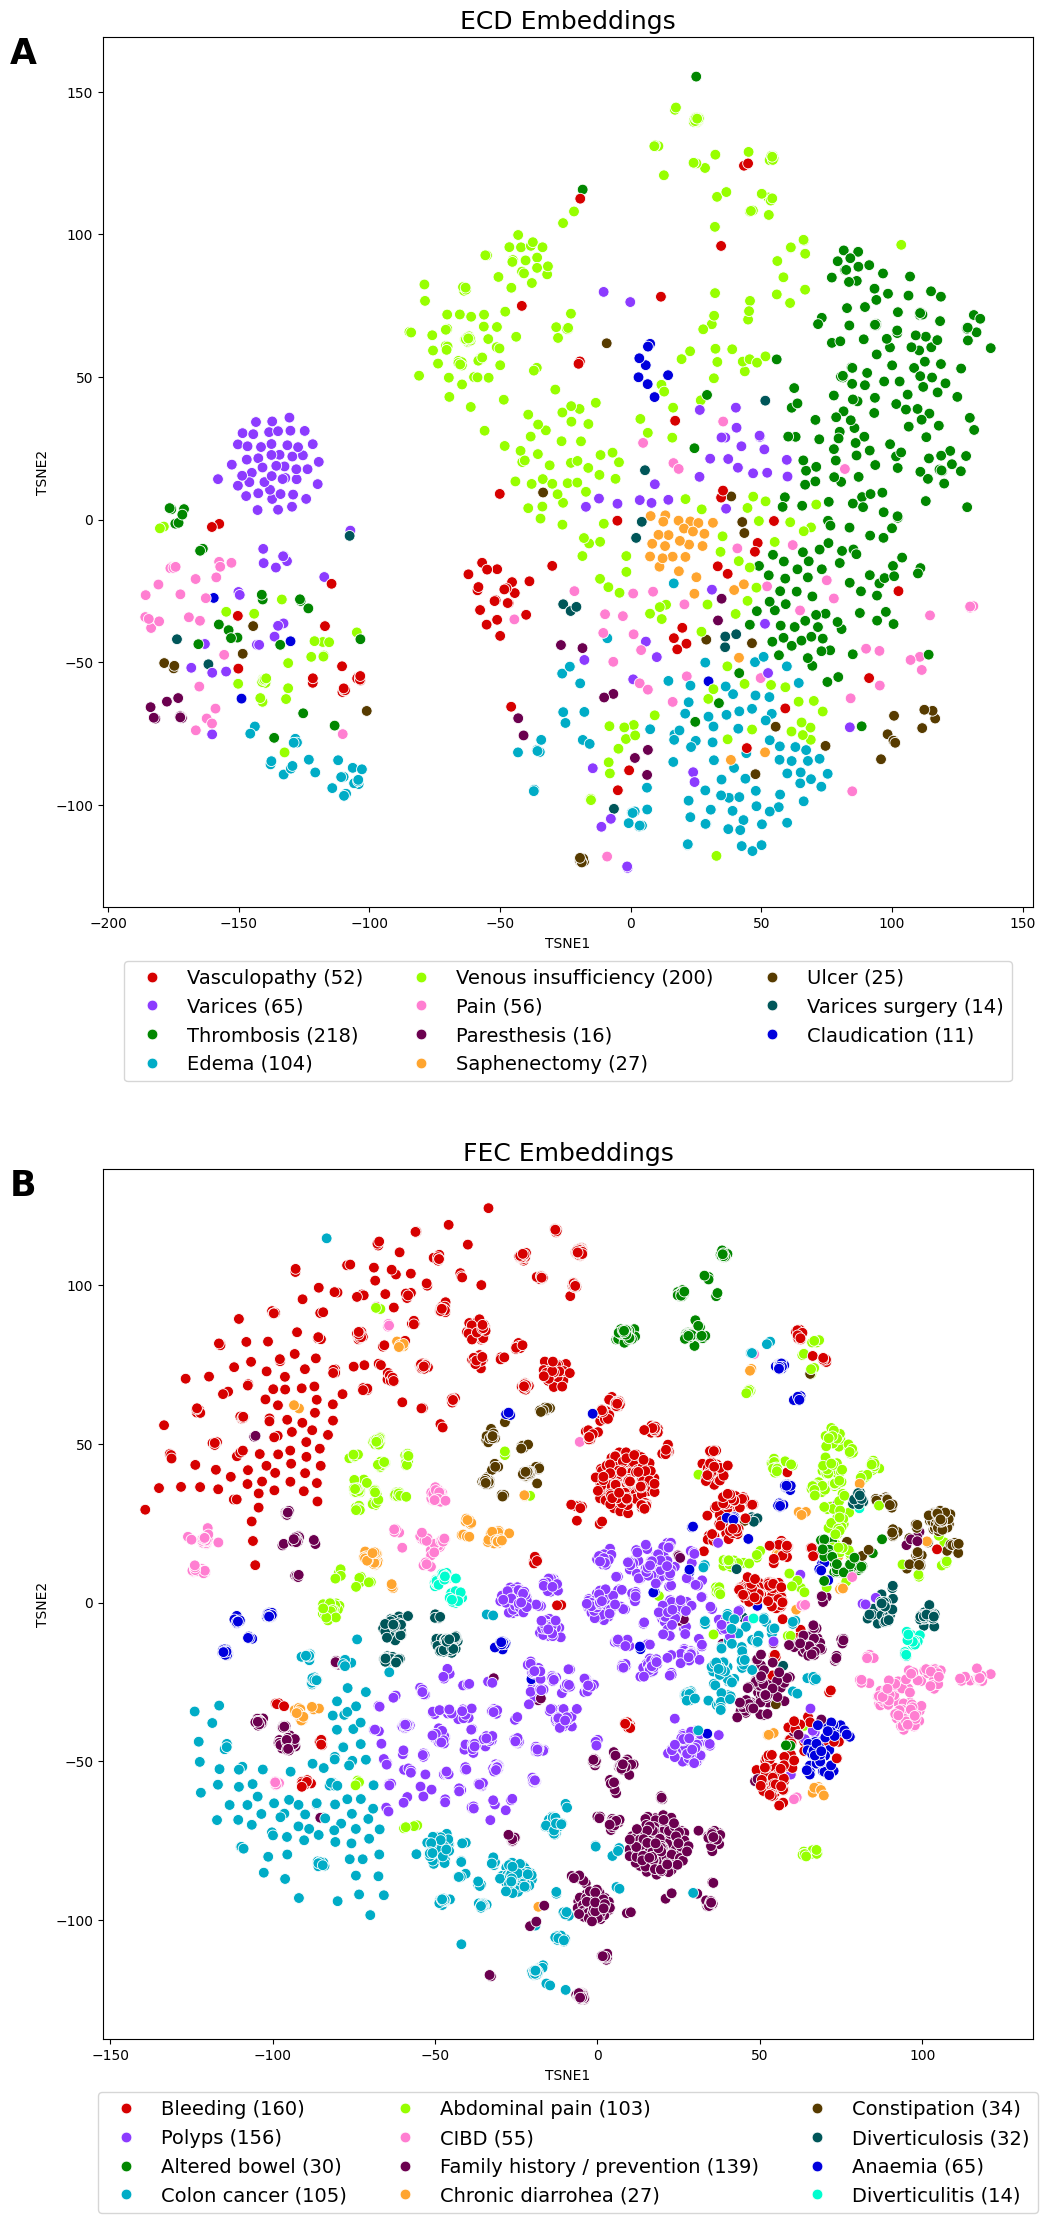

In [ ]:
#fig.gca().figure.tight_layout()
fig.gca().figure.subplots_adjust(hspace=0.3)
fig.gca().figure

In [ ]:
fig.savefig("tsne_fec_ecd_2x1.pdf", bbox_inches="tight", dpi=300)